# Session Duration Analysis in WildChat

**Purpose:** Calculate session duration metrics for training data users by grouping conversations with <15 minute gaps, then analyze session duration patterns by toxicity.

**Dataset:** WildChat training data (conversations starting before 2025-01-01)

---

## Methodology

1. **Conversation Duration**: Time between first and last turn in each conversation
2. **Session Definition**: Group conversations with <15 minute gaps between end of previous and start of next
3. **Session Duration**: Sum of conversation durations + gaps within session
4. **Session Toxicity**: Ratio of toxic conversations to total conversations in session

---

## Contents

1. Setup and Brand Configuration
2. Load Training Data and Filter
3. Explode Conversations to Turn Level
4. Calculate Conversation Durations
5. Join with User Data
6. Group Conversations into Sessions
7. Calculate Session Metrics
8. Extract User Geographic Information
9. Map Country/State to Timezone
10. Classify Sessions as Daytime or Evening
11. Calculate Sessions Per Week Per User
12. Identify Users with >=1 Session >= 6 Hours
13. Visualization and Summary Statistics


In [1]:
# ============================================================
# Setup & Brand Configuration
# ============================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
import os
import re
import gc
import glob
import json
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directory
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# =============================================================================
# PHRONOS BRAND COLORS (Light Mode)
# =============================================================================
BRAND = {
    'paper': '#F2F0E9',           # Primary background
    'ink': '#1A1A1A',             # Primary text/axes
    'gold': '#B08D55',            # Accent, highlights, signal
    'gold_dim': 'rgba(176, 141, 85, 0.12)',
    'faded': 'rgba(26, 26, 26, 0.5)',      # Secondary text
    'faded_light': 'rgba(26, 26, 26, 0.08)', # Borders, dividers
    'white': '#FFFFFF',           # Card backgrounds
    'alert': '#CC5544',           # Critical, errors (used for toxic)
    'success': '#44AA77',         # Positive states
}

# Convert rgba strings to matplotlib-compatible format
def rgba_to_tuple(rgba_str):
    """Convert 'rgba(r,g,b,a)' string to matplotlib tuple."""
    match = re.match(r'rgba\((\d+),\s*(\d+),\s*(\d+),\s*([\d.]+)\)', rgba_str)
    if match:
        r, g, b, a = match.groups()
        return (int(r)/255, int(g)/255, int(b)/255, float(a))
    return rgba_str

FADED = rgba_to_tuple('rgba(26, 26, 26, 0.5)')
FADED_LIGHT = rgba_to_tuple('rgba(26, 26, 26, 0.08)')

# =============================================================================
# MATPLOTLIB CONFIGURATION
# =============================================================================
plt.rcParams.update({
    # Figure
    'figure.facecolor': BRAND['paper'],
    'figure.edgecolor': BRAND['ink'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.facecolor': BRAND['paper'],
    'savefig.edgecolor': 'none',
    
    # Axes
    'axes.facecolor': BRAND['paper'],
    'axes.edgecolor': BRAND['ink'],
    'axes.labelcolor': BRAND['ink'],
    'axes.titlecolor': BRAND['ink'],
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'axes.axisbelow': True,
    
    # Grid
    'grid.color': FADED_LIGHT,
    'grid.linewidth': 0.5,
    'grid.alpha': 1.0,
    
    # Ticks
    'xtick.color': BRAND['ink'],
    'ytick.color': BRAND['ink'],
    'xtick.labelcolor': BRAND['ink'],
    'ytick.labelcolor': BRAND['ink'],
    
    # Text
    'text.color': BRAND['ink'],
    
    # Font - Use Fira Code for labels, fallback to monospace
    'font.family': 'monospace',
    'font.monospace': ['Fira Code', 'Consolas', 'Monaco', 'monospace'],
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    
    # Legend
    'legend.facecolor': BRAND['white'],
    'legend.edgecolor': BRAND['ink'],
    'legend.framealpha': 1.0,
})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_phronos_style(ax, title=None, xlabel=None, ylabel=None):
    """Apply Phronos brand styling to an axes object."""
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'], which='both')
    ax.grid(True, alpha=0.3, color=BRAND['ink'], linewidth=0.5)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', color=BRAND['ink'])
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=BRAND['ink'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=BRAND['ink'])

def save_figure(fig, name, tight=True):
    """Save figure with Phronos styling."""
    path = f'../outputs/figures/pub_{name}.png'
    if tight:
        fig.savefig(path, dpi=300, bbox_inches='tight', 
                    facecolor=BRAND['paper'], edgecolor='none')
    else:
        fig.savefig(path, dpi=300, facecolor=BRAND['paper'], edgecolor='none')
    print(f"Saved: {path}")
    return path

print("Phronos brand configuration loaded.")
print(f"  Paper: {BRAND['paper']}")
print(f"  Ink: {BRAND['ink']}")
print(f"  Gold: {BRAND['gold']}")
print(f"  Random state: {RANDOM_STATE}")


Phronos brand configuration loaded.
  Paper: #F2F0E9
  Ink: #1A1A1A
  Gold: #B08D55
  Random state: 42


In [2]:
# ============================================================
# Load Training Data and Filter
# ============================================================

print("="*70)
print("LOADING TRAINING DATA")
print("="*70)

# Data paths
PROTEST_USERS = '../outputs/data/protest_with_users/*.parquet'
RAW_DATA = '../data/wildchat-raw/data/*.parquet'

# Load preprocessed data with user IDs
print("Loading data...")
df = pl.scan_parquet(PROTEST_USERS).collect()
print(f"Loaded {len(df):,} conversations")

# CRITICAL: Deduplicate immediately after loading
df = df.unique(subset=['conversation_hash'])
print(f"After deduplication: {len(df):,} unique conversations")

# Filter to training data: conversations starting before 2025-01-01
TRAIN_TEST_CUTOFF = pl.date(2025, 1, 1)
print(f"\nFiltering to training data (timestamp < {TRAIN_TEST_CUTOFF})...")
df_train = df.filter(pl.col('timestamp') < TRAIN_TEST_CUTOFF)
print(f"Training conversations: {len(df_train):,}")

# Get unique conversation hashes for training data
train_conv_hashes = set(df_train['conversation_hash'].to_list())
print(f"Unique training conversation hashes: {len(train_conv_hashes):,}")

# Get user statistics
print(f"\nUnique users in training data: {df_train['user_id'].n_unique():,}")

print("\n" + "="*70)
print("Data loading complete.")
print("="*70)


LOADING TRAINING DATA
Loading data...
Loaded 4,743,336 conversations
After deduplication: 4,292,113 unique conversations

Filtering to training data (timestamp < 2025-01-01 00:00:00.alias("datetime").strict_cast(Date).alias("date"))...
Training conversations: 3,094,322
Unique training conversation hashes: 3,094,322

Unique users in training data: 1,670,926

Data loading complete.


In [3]:
# ============================================================
# Explode Conversations to Turn Level
# ============================================================
# CRITICAL: Use dict-based deduplication when processing file-by-file
# Pattern from notebook 09, Cell 4

print("="*70)
print("EXPLODING CONVERSATIONS TO TURN LEVEL")
print("="*70)

def extract_turns_from_conversation(conversation, conversation_hash):
    """Extract turn-level timestamps from conversation."""
    if conversation is None:
        return []
    
    try:
        # Parse if string
        if isinstance(conversation, str):
            conv_list = json.loads(conversation)
        else:
            conv_list = conversation
        
        turns = []
        for turn_idx, turn in enumerate(conv_list):
            if isinstance(turn, dict):
                turn_timestamp = turn.get('timestamp')
                if turn_timestamp:
                    # Store raw timestamp - Polars will handle conversion
                    turns.append({
                        'conversation_hash': conversation_hash,
                        'turn_index': turn_idx,
                        'turn_timestamp': turn_timestamp,
                    })
        return turns
    except Exception as e:
        return []

# Get list of parquet files
parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Raw data files: {len(parquet_files)}")

# CRITICAL: Use dict-based deduplication (conversation_hash as key)
# This automatically handles duplicates across files
conversation_turns = {}  # Dict: conversation_hash -> list of turns
conversation_toxic = {}  # Dict: conversation_hash -> toxic flag

print(f"Target conversation hashes: {len(train_conv_hashes):,}")
print("\nProcessing raw data files...")

for file_idx, parquet_file in enumerate(parquet_files):
    # Load only needed columns
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation', 'toxic'])
    
    # Filter to our target hashes
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(train_conv_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # Extract turns for each conversation
    for row in file_filtered.iter_rows(named=True):
        conv_hash = row['conversation_hash']
        
        # CRITICAL: Check if already seen (auto-deduplication)
        if conv_hash not in conversation_turns:
            turns = extract_turns_from_conversation(row['conversation'], conv_hash)
            if turns:
                conversation_turns[conv_hash] = turns
                # Store toxic flag
                conversation_toxic[conv_hash] = row.get('toxic', False)
    
    # Progress update
    if (file_idx + 1) % 20 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(conversation_turns):,} conversations...")
    
    # Clean up memory
    del file_data, file_filtered
    gc.collect()

print(f"\nExtracted turns from {len(conversation_turns):,} conversations")

# Create turn-level dataframe
all_turns = []
for conv_hash, turns in conversation_turns.items():
    for turn in turns:
        all_turns.append({
            'conversation_hash': conv_hash,
            'turn_index': turn['turn_index'],
            'turn_timestamp': turn['turn_timestamp'],
            'toxic': conversation_toxic.get(conv_hash, False),
        })

turn_df = pl.DataFrame(all_turns)
print(f"Total turns extracted: {len(turn_df):,}")

# CRITICAL: Deduplicate before joining with user data
turn_df = turn_df.unique(subset=['conversation_hash', 'turn_index'])
print(f"After deduplication: {len(turn_df):,} unique turns")

# Convert timestamp to datetime - handle different input formats
# Check if timestamp is already datetime
if turn_df['turn_timestamp'].dtype != pl.Datetime:
    # Try to convert - Polars will handle epoch timestamps or string dates
    try:
        turn_df = turn_df.with_columns([
            pl.col('turn_timestamp').cast(pl.Datetime(time_unit='us', strict=False)).alias('turn_timestamp')
        ])
    except:
        # If cast fails, try parsing as string
        try:
            turn_df = turn_df.with_columns([
                pl.col('turn_timestamp').str.strptime(pl.Datetime, format='%Y-%m-%d %H:%M:%S').alias('turn_timestamp')
            ])
        except:
            print("  Warning: Could not convert all timestamps to datetime. Some may be missing.")

print("\n" + "="*70)
print("Turn extraction complete.")
print("="*70)


EXPLODING CONVERSATIONS TO TURN LEVEL
Raw data files: 127
Target conversation hashes: 3,094,322

Processing raw data files...
  Processed 20/127 files, found 738,481 conversations...
  Processed 40/127 files, found 1,460,991 conversations...
  Processed 60/127 files, found 2,107,475 conversations...
  Processed 80/127 files, found 2,836,667 conversations...
  Processed 100/127 files, found 3,094,322 conversations...
  Processed 120/127 files, found 3,094,322 conversations...

Extracted turns from 3,094,322 conversations
Total turns extracted: 5,751,441
After deduplication: 5,751,441 unique turns

Turn extraction complete.


In [4]:
# ============================================================
# Calculate Conversation Durations
# ============================================================

print("="*70)
print("CALCULATING CONVERSATION DURATIONS")
print("="*70)

# Group by conversation_hash to find first and last turn timestamps
conv_duration_df = turn_df.group_by('conversation_hash').agg([
    pl.col('turn_timestamp').min().alias('conversation_start'),
    pl.col('turn_timestamp').max().alias('conversation_end'),
    pl.col('toxic').first().alias('toxic'),  # Toxic flag is same for all turns in conversation
    pl.len().alias('n_turns'),  # Count turns per conversation
])

# Calculate conversation duration
conv_duration_df = conv_duration_df.with_columns([
    (pl.col('conversation_end') - pl.col('conversation_start'))
    .dt.total_seconds()
    .alias('conversation_duration_seconds')
])

# Convert to minutes for readability
conv_duration_df = conv_duration_df.with_columns([
    (pl.col('conversation_duration_seconds') / 60.0).alias('conversation_duration_minutes')
])

print(f"Conversations with duration calculated: {len(conv_duration_df):,}")

# Summary statistics
print("\nConversation duration statistics:")
print(f"  Mean: {conv_duration_df['conversation_duration_minutes'].mean():.2f} minutes")
print(f"  Median: {conv_duration_df['conversation_duration_minutes'].median():.2f} minutes")
print(f"  Min: {conv_duration_df['conversation_duration_minutes'].min():.2f} minutes")
print(f"  Max: {conv_duration_df['conversation_duration_minutes'].max():.2f} minutes")

# Count conversations with duration = 0 (all turns at same timestamp)
zero_duration = (conv_duration_df['conversation_duration_minutes'] == 0).sum()
print(f"  Conversations with duration=0: {zero_duration:,} ({100*zero_duration/len(conv_duration_df):.1f}%)")

# Show turn count distribution
print(f"\nTurn count distribution:")
print(f"  Mean turns per conversation: {conv_duration_df['n_turns'].mean():.1f}")
print(f"  Median turns per conversation: {conv_duration_df['n_turns'].median():.0f}")
print(f"  Min turns: {conv_duration_df['n_turns'].min()}")
print(f"  Max turns: {conv_duration_df['n_turns'].max()}")

# CRITICAL: Deduplicate before joining
conv_duration_df = conv_duration_df.unique(subset=['conversation_hash'])
print(f"\nAfter deduplication: {len(conv_duration_df):,} unique conversations")

print("\n" + "="*70)
print("Conversation duration calculation complete.")
print("="*70)


CALCULATING CONVERSATION DURATIONS
Conversations with duration calculated: 3,094,322

Conversation duration statistics:
  Mean: 16.85 minutes
  Median: 0.00 minutes
  Min: 0.00 minutes
  Max: 69192.88 minutes
  Conversations with duration=0: 2,472,659 (79.9%)

Turn count distribution:
  Mean turns per conversation: 1.9
  Median turns per conversation: 1
  Min turns: 1
  Max turns: 500

After deduplication: 3,094,322 unique conversations

Conversation duration calculation complete.


In [5]:
# ============================================================
# Join with User Data
# ============================================================
# CRITICAL: Deduplicate both sides before join (pattern from notebook 08, Cell 3)

print("="*70)
print("JOINING WITH USER DATA")
print("="*70)

# Prepare user dataframe with conversation_hash and user_id
user_df = df_train.select(['conversation_hash', 'user_id', 'timestamp'])

# CRITICAL: Deduplicate both DataFrames before join
user_df_dedup = user_df.unique(subset=['conversation_hash'])
conv_duration_df_dedup = conv_duration_df.unique(subset=['conversation_hash'])

print(f"User dataframe (deduplicated): {len(user_df_dedup):,} conversations")
print(f"Conversation duration dataframe (deduplicated): {len(conv_duration_df_dedup):,} conversations")

# Join on conversation_hash
final_df = user_df_dedup.join(
    conv_duration_df_dedup,
    on='conversation_hash',
    how='inner'
)

print(f"\nJoined dataframe: {len(final_df):,} conversations")
print(f"Unique users: {final_df['user_id'].n_unique():,}")

# Verify join quality
missing_users = len(user_df_dedup) - len(final_df)
if missing_users > 0:
    print(f"  Warning: {missing_users:,} conversations from user_df not found in conv_duration_df")

missing_conv = len(conv_duration_df_dedup) - len(final_df)
if missing_conv > 0:
    print(f"  Warning: {missing_conv:,} conversations from conv_duration_df not found in user_df")

# Sort by user_id and conversation_start for session grouping
final_df = final_df.sort(['user_id', 'conversation_start'])

# Filter out users who only had 1 conversation that was <=2 turns
# (These users can't contribute to session analysis)
print("\nFiltering out users with only 1 conversation (≤2 turns)...")

# Count conversations per user and get turn count for single-conversation users
user_conv_counts = final_df.group_by('user_id').agg([
    pl.len().alias('n_conversations'),
    pl.col('n_turns').min().alias('min_turns'),  # For single-conversation users, this is their only conversation's turn count
])

# Identify users to exclude: only 1 conversation AND that conversation has <=2 turns
users_to_exclude = user_conv_counts.filter(
    (pl.col('n_conversations') == 1) & (pl.col('min_turns') <= 2)
)['user_id'].to_list()

n_users_before = final_df['user_id'].n_unique()
n_convs_before = len(final_df)
final_df = final_df.filter(~pl.col('user_id').is_in(users_to_exclude))
n_users_after = final_df['user_id'].n_unique()
n_convs_after = len(final_df)

print(f"  Users before filtering: {n_users_before:,}")
print(f"  Users excluded: {len(users_to_exclude):,}")
print(f"  Users after filtering: {n_users_after:,}")
print(f"  Conversations before filtering: {n_convs_before:,}")
print(f"  Conversations after filtering: {n_convs_after:,}")

print("\n" + "="*70)
print("Join complete.")
print("="*70)


JOINING WITH USER DATA
User dataframe (deduplicated): 3,094,322 conversations
Conversation duration dataframe (deduplicated): 3,094,322 conversations

Joined dataframe: 3,094,322 conversations
Unique users: 1,670,926

Filtering out users with only 1 conversation (≤2 turns)...
  Users before filtering: 1,670,926
  Users excluded: 1,448,883
  Users after filtering: 222,043
  Conversations before filtering: 3,094,322
  Conversations after filtering: 1,645,439

Join complete.


In [6]:
# ============================================================
# Group Conversations into Sessions
# ============================================================
# Sessions: conversations with <30 minute gaps between end of previous and start of next

print("="*70)
print("GROUPING CONVERSATIONS INTO SESSIONS")
print("="*70)

SESSION_GAP_MINUTES = 30  # Gap threshold for session grouping

# Group by user_id and assign session IDs
print("Assigning session IDs...")

# Use map_groups to assign session IDs
session_assignments = []
for user_id in final_df['user_id'].unique().to_list():
    user_convs = final_df.filter(pl.col('user_id') == user_id).sort('conversation_start')
    
    session_id = 0
    for i in range(len(user_convs)):
        if i == 0:
            session_assignments.append((user_convs['conversation_hash'][i], session_id))
        else:
            prev_end = user_convs['conversation_end'][i-1]
            curr_start = user_convs['conversation_start'][i]
            
            # When accessing individual values, subtraction returns Python timedelta
            gap_minutes = (curr_start - prev_end).total_seconds() / 60.0
            
            if gap_minutes >= SESSION_GAP_MINUTES:
                session_id += 1
            
            session_assignments.append((user_convs['conversation_hash'][i], session_id))

# Create session mapping dataframe
session_map = pl.DataFrame(session_assignments, schema=['conversation_hash', 'session_id'])

# Join session IDs back to final_df
final_df = final_df.join(session_map, on='conversation_hash', how='left')

# Create unique session identifier: user_id + session_id
final_df = final_df.with_columns([
    (pl.col('user_id').cast(pl.Utf8) + '_' + pl.col('session_id').cast(pl.Utf8)).alias('unique_session_id')
])

print(f"Total sessions created: {final_df['unique_session_id'].n_unique():,}")
print(f"Average conversations per session: {len(final_df) / final_df['unique_session_id'].n_unique():.2f}")

# Summary by user
user_session_stats = final_df.group_by('user_id').agg([
    pl.col('unique_session_id').n_unique().alias('n_sessions'),
    pl.len().alias('n_conversations'),
])

print(f"\nSession statistics:")
print(f"  Mean sessions per user: {user_session_stats['n_sessions'].mean():.2f}")
print(f"  Median sessions per user: {user_session_stats['n_sessions'].median():.2f}")
print(f"  Max sessions per user: {user_session_stats['n_sessions'].max():,}")

print("\n" + "="*70)
print("Session grouping complete.")
print("="*70)


GROUPING CONVERSATIONS INTO SESSIONS
Assigning session IDs...
Total sessions created: 622,589
Average conversations per session: 2.64

Session statistics:
  Mean sessions per user: 2.80
  Median sessions per user: 1.00
  Max sessions per user: 1,800

Session grouping complete.


In [7]:
# ============================================================
# Calculate Session Metrics
# ============================================================

print("="*70)
print("CALCULATING SESSION METRICS")
print("="*70)

# Use Polars group_by for efficient aggregation instead of Python loop
# Sort by session and conversation start to calculate gaps correctly
final_df_sorted = final_df.sort(['unique_session_id', 'conversation_start'])

# Calculate gaps between consecutive conversations within each session
# Use window function to get previous conversation_end
final_df_with_gaps = final_df_sorted.with_columns([
    pl.col('conversation_end').shift(1).over('unique_session_id').alias('prev_conversation_end')
]).with_columns([
    # Calculate gap in minutes (only for conversations after the first in each session)
    pl.when(pl.col('prev_conversation_end').is_not_null())
    .then((pl.col('conversation_start') - pl.col('prev_conversation_end')).dt.total_seconds() / 60.0)
    .otherwise(0.0)
    .alias('gap_minutes')
])

# Aggregate by session using group_by (much faster than Python loop)
session_df = final_df_with_gaps.group_by('unique_session_id').agg([
    pl.col('user_id').first().alias('user_id'),
    pl.col('conversation_start').min().alias('session_start'),
    pl.col('conversation_end').max().alias('session_end'),
    pl.col('conversation_duration_minutes').sum().alias('total_conv_duration'),
    pl.col('gap_minutes').sum().alias('total_gaps'),
    pl.col('toxic').sum().alias('n_toxic_conversations'),
    pl.len().alias('n_conversations'),
]).with_columns([
    # Session duration = sum of conversation durations + gaps between conversations
    (pl.col('total_conv_duration') + pl.col('total_gaps')).alias('session_duration_minutes'),
    # Session toxicity ratio
    (pl.col('n_toxic_conversations') / pl.col('n_conversations')).alias('session_toxicity_ratio')
]).select([
    'unique_session_id',
    'user_id',
    'session_start',
    'session_end',
    'session_duration_minutes',
    'session_toxicity_ratio',
    'n_conversations',
    'n_toxic_conversations',
])

print(f"Total sessions: {len(session_df):,}")
print(f"Unique users: {session_df['user_id'].n_unique():,}")

# Summary statistics
print("\nSession duration statistics:")
print(f"  Mean: {session_df['session_duration_minutes'].mean():.2f} minutes")
print(f"  Median: {session_df['session_duration_minutes'].median():.2f} minutes")
print(f"  Min: {session_df['session_duration_minutes'].min():.2f} minutes")
print(f"  Max: {session_df['session_duration_minutes'].max():.2f} minutes")

print("\nSession toxicity statistics:")
print(f"  Mean toxicity ratio: {session_df['session_toxicity_ratio'].mean():.3f}")
print(f"  Sessions with ≥50% toxic: {(session_df['session_toxicity_ratio'] >= 0.5).sum():,} ({(session_df['session_toxicity_ratio'] >= 0.5).sum() / len(session_df) * 100:.1f}%)")
print(f"  Sessions with 100% toxic: {(session_df['session_toxicity_ratio'] == 1.0).sum():,} ({(session_df['session_toxicity_ratio'] == 1.0).sum() / len(session_df) * 100:.1f}%)")
print(f"  Sessions with 0% toxic: {(session_df['session_toxicity_ratio'] == 0.0).sum():,} ({(session_df['session_toxicity_ratio'] == 0.0).sum() / len(session_df) * 100:.1f}%)")

# Create binary toxicity flag for visualization
session_df = session_df.with_columns([
    (pl.col('session_toxicity_ratio') >= 0.5).alias('is_toxic_session')
])

# Calculate inter-session gaps (time between consecutive sessions for each user)
print("\nCalculating inter-session gaps...")

# Use Polars group_by and window functions for efficient gap calculation
# Sort by user and session start
session_df_sorted = session_df.sort(['user_id', 'session_start'])

# Calculate gaps between consecutive sessions for each user using window function
session_df_with_inter_gaps = session_df_sorted.with_columns([
    pl.col('session_end').shift(1).over('user_id').alias('prev_session_end')
]).with_columns([
    # Calculate gap in minutes (only for sessions after the first for each user)
    pl.when(pl.col('prev_session_end').is_not_null())
    .then((pl.col('session_start') - pl.col('prev_session_end')).dt.total_seconds() / 60.0)
    .otherwise(None)
    .alias('inter_session_gap_minutes')
])

# Extract all inter-session gaps (filter out None values and negative/overlapping sessions)
# Negative gaps indicate overlapping sessions (shouldn't happen with proper session grouping)
# Filter them out for statistics
inter_session_gaps_df = session_df_with_inter_gaps.filter(
    pl.col('inter_session_gap_minutes').is_not_null()
)

# Filter out negative gaps (overlapping sessions) for statistics
# Only include valid positive gaps
inter_session_gaps = inter_session_gaps_df.filter(
    pl.col('inter_session_gap_minutes') > 0
)['inter_session_gap_minutes'].to_list()

# Store gaps for later use in summary statistics
if len(inter_session_gaps) > 0:
    mean_gap = np.mean(inter_session_gaps)
    median_gap = np.median(inter_session_gaps)
    n_negative_filtered = len(inter_session_gaps_df) - len(inter_session_gaps)
    print(f"  Inter-session gaps calculated: {len(inter_session_gaps):,} valid gaps")
    if n_negative_filtered > 0:
        print(f"  (Excluded {n_negative_filtered:,} overlapping sessions with negative gaps)")
    print(f"  Mean gap: {mean_gap:.2f} minutes")
    print(f"  Median gap: {median_gap:.2f} minutes")
    print(f"  Min gap: {np.min(inter_session_gaps):.2f} minutes")
    print(f"  Max gap: {np.max(inter_session_gaps):.2f} minutes")
else:
    print("  No inter-session gaps to calculate (all users have only 1 session)")

print("\n" + "="*70)
print("Session metrics calculation complete.")
print("="*70)


CALCULATING SESSION METRICS
Total sessions: 622,589
Unique users: 222,043

Session duration statistics:
  Mean: 79.84 minutes
  Median: 7.30 minutes
  Min: 0.00 minutes
  Max: 61201.63 minutes

Session toxicity statistics:
  Mean toxicity ratio: 0.157
  Sessions with ≥50% toxic: 103,940 (16.7%)
  Sessions with 100% toxic: 76,186 (12.2%)
  Sessions with 0% toxic: 496,984 (79.8%)

Calculating inter-session gaps...
  Inter-session gaps calculated: 398,682 valid gaps
  (Excluded 1,864 overlapping sessions with negative gaps)
  Mean gap: 3512.03 minutes
  Median gap: 552.34 minutes
  Min gap: 0.02 minutes
  Max gap: 774689.07 minutes

Session metrics calculation complete.


EXTRACTING USER GEOGRAPHIC INFORMATION
Extracting country and state from conversations...
Processing 127 raw data files...
Target conversations: 1,645,439
  Processed 20/127 files, found 660,047 conversations...
  Processed 40/127 files, found 1,313,600 conversations...
  Processed 60/127 files, found 1,459,218 conversations...
  Processed 80/127 files, found 1,503,653 conversations...
  Processed 100/127 files, found 1,645,439 conversations...
  Processed 120/127 files, found 1,645,439 conversations...

Extracted geographic data for 1,645,439 conversations
Geographic data for 222,043 users
Users with country info: 221,403
Users with state info: 178,726

Top 10 countries:
  Russia: 33,814 users
  United States: 27,372 users
  China: 25,006 users
  Hong Kong: 10,481 users
  India: 8,687 users
  Germany: 6,279 users
  France: 5,711 users
  Japan: 5,352 users
  Egypt: 5,058 users
  Iran: 4,550 users

Geographic extraction complete.
Saved: ../outputs/figures/pub_session_duration_by_toxicit

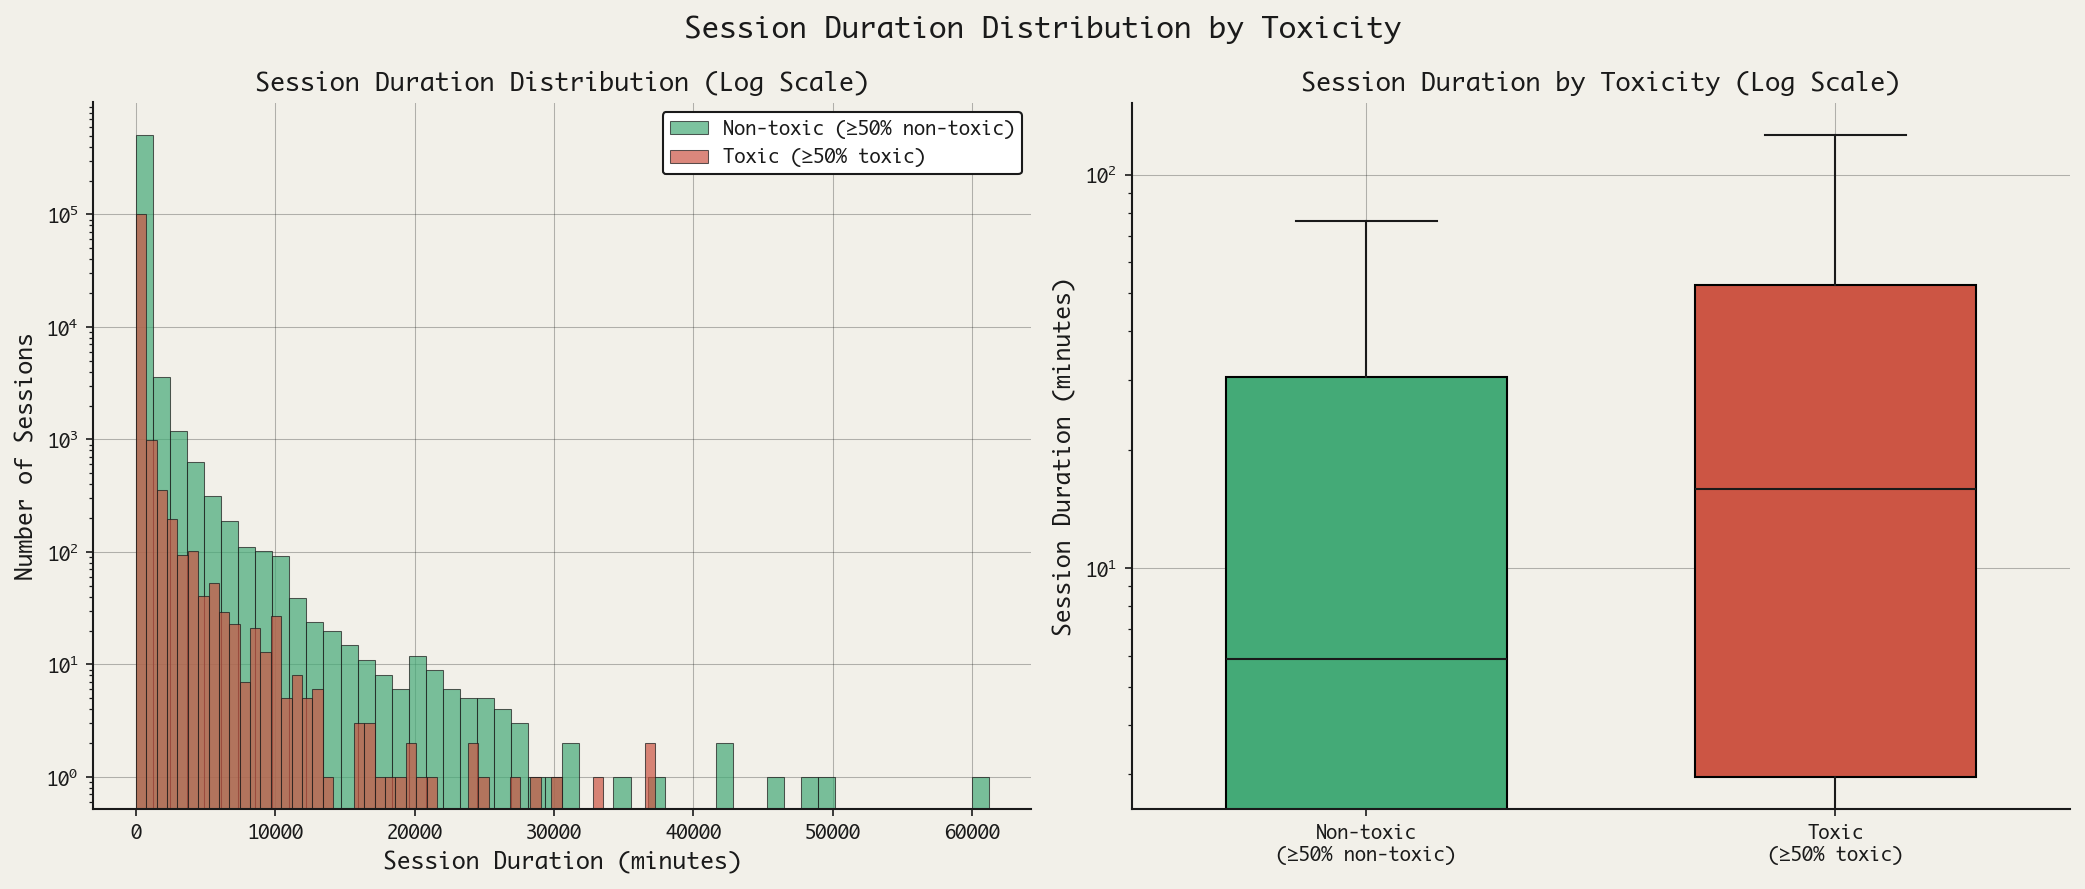


Statistical comparison:
  Non-toxic sessions (n=518,649):
    Mean: 76.52 minutes
    Median: 5.88 minutes
  Toxic sessions (n=103,940):
    Mean: 96.43 minutes
    Median: 15.93 minutes

  Mann-Whitney U test:
    U-statistic: 21,103,360,623
    p-value: 0.00e+00
    *** Significant difference (p < 0.001) ***

Saved session metrics to: ../outputs/data/session_metrics.parquet

Analysis complete.


In [8]:
# ============================================================
# Extract User Geographic Information
# ============================================================

print("="*70)
print("EXTRACTING USER GEOGRAPHIC INFORMATION")
print("="*70)

# Extract country and state from user's conversations
# Use the most common country/state for each user
print("Extracting country and state from conversations...")

# Load country/state from raw data for conversations in final_df
user_geo_data = {}  # Dict: conversation_hash -> (country, state)

parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Processing {len(parquet_files)} raw data files...")

# Get conversation hashes we need
target_hashes = set(final_df['conversation_hash'].to_list())
print(f"Target conversations: {len(target_hashes):,}")

for file_idx, parquet_file in enumerate(parquet_files):
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'country', 'state'])
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(target_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # Extract country/state for each conversation
    for row in file_filtered.iter_rows(named=True):
        conv_hash = row['conversation_hash']
        if conv_hash not in user_geo_data:
            user_geo_data[conv_hash] = (
                row.get('country') or None,
                row.get('state') or None
            )
    
    if (file_idx + 1) % 20 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(user_geo_data):,} conversations...")
    
    del file_data, file_filtered
    gc.collect()

print(f"\nExtracted geographic data for {len(user_geo_data):,} conversations")

# Create geo dataframe
geo_df = pl.DataFrame([
    {'conversation_hash': k, 'country': v[0], 'state': v[1]}
    for k, v in user_geo_data.items()
])

# Join with final_df to get user_id
geo_with_user = final_df.select(['conversation_hash', 'user_id']).join(
    geo_df,
    on='conversation_hash',
    how='left'
)

# Get most common country and state per user
user_geo = geo_with_user.group_by('user_id').agg([
    pl.col('country').value_counts().first().struct.field('country').first().alias('user_country'),
    pl.col('state').value_counts().first().struct.field('state').first().alias('user_state'),
])

print(f"Geographic data for {len(user_geo):,} users")
print(f"Users with country info: {user_geo.filter(pl.col('user_country').is_not_null())['user_id'].n_unique():,}")
print(f"Users with state info: {user_geo.filter(pl.col('user_state').is_not_null())['user_id'].n_unique():,}")

# Show top countries
top_countries = user_geo.filter(pl.col('user_country').is_not_null()).group_by('user_country').agg([
    pl.len().alias('n_users')
]).sort('n_users', descending=True).head(10)
print("\nTop 10 countries:")
for row in top_countries.iter_rows(named=True):
    print(f"  {row['user_country']}: {row['n_users']:,} users")

print("\n" + "="*70)
print("Geographic extraction complete.")
print("="*70)

# Create histogram of session duration grouped by toxicity
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Session Duration Distribution by Toxicity', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Histogram
ax = axes[0]
toxic_sessions = session_df.filter(pl.col('is_toxic_session') == True)['session_duration_minutes'].to_numpy()
non_toxic_sessions = session_df.filter(pl.col('is_toxic_session') == False)['session_duration_minutes'].to_numpy()

# Use log scale for better visualization (many short sessions)
ax.hist(non_toxic_sessions, bins=50, alpha=0.7, label='Non-toxic (≥50% non-toxic)', 
        color=BRAND['success'], edgecolor=BRAND['ink'], linewidth=0.5)
ax.hist(toxic_sessions, bins=50, alpha=0.7, label='Toxic (≥50% toxic)', 
        color=BRAND['alert'], edgecolor=BRAND['ink'], linewidth=0.5)

ax.set_xlabel('Session Duration (minutes)', fontsize=11, color=BRAND['ink'])
ax.set_ylabel('Number of Sessions', fontsize=11, color=BRAND['ink'])
ax.set_yscale('log')
ax.set_title('Session Duration Distribution (Log Scale)', fontsize=12, fontweight='bold', color=BRAND['ink'])
ax.legend(fontsize=9, framealpha=1.0, facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

# Panel 2: Box plot comparison
ax = axes[1]
box_data = [non_toxic_sessions, toxic_sessions]
box_labels = ['Non-toxic\n(≥50% non-toxic)', 'Toxic\n(≥50% toxic)']
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, 
                widths=0.6, showfliers=False)

# Color the boxes
bp['boxes'][0].set_facecolor(BRAND['success'])
bp['boxes'][1].set_facecolor(BRAND['alert'])
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    if element in bp:
        for item in bp[element]:
            item.set_color(BRAND['ink'])

ax.set_ylabel('Session Duration (minutes)', fontsize=11, color=BRAND['ink'])
ax.set_yscale('log')
ax.set_title('Session Duration by Toxicity (Log Scale)', fontsize=12, fontweight='bold', color=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'session_duration_by_toxicity')
plt.show()

# Statistical comparison
print("\nStatistical comparison:")
print(f"  Non-toxic sessions (n={len(non_toxic_sessions):,}):")
print(f"    Mean: {np.mean(non_toxic_sessions):.2f} minutes")
print(f"    Median: {np.median(non_toxic_sessions):.2f} minutes")
print(f"  Toxic sessions (n={len(toxic_sessions):,}):")
print(f"    Mean: {np.mean(toxic_sessions):.2f} minutes")
print(f"    Median: {np.median(toxic_sessions):.2f} minutes")

# Mann-Whitney U test (non-parametric, handles skewed distributions)
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(non_toxic_sessions, toxic_sessions, alternative='two-sided')
print(f"\n  Mann-Whitney U test:")
print(f"    U-statistic: {statistic:,.0f}")
print(f"    p-value: {p_value:.2e}")

if p_value < 0.001:
    print("    *** Significant difference (p < 0.001) ***")
elif p_value < 0.01:
    print("    ** Significant difference (p < 0.01) **")
elif p_value < 0.05:
    print("    * Significant difference (p < 0.05) *")
else:
    print("    No significant difference")

# Save session dataframe
output_path = '../outputs/data/session_metrics.parquet'
session_df.write_parquet(output_path)
print(f"\nSaved session metrics to: {output_path}")

print("\n" + "="*70)
print("Analysis complete.")
print("="*70)


In [9]:
# ============================================================
# Map Country/State to Timezone
# ============================================================

print("="*70)
print("MAPPING COUNTRY/STATE TO TIMEZONE")
print("="*70)

try:
    import pytz
    from datetime import datetime
except ImportError:
    import subprocess
    import sys
    print("Installing pytz...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytz"])
    import pytz
    from datetime import datetime

# Mapping of country names to timezones
# For US states, we'll use state-specific timezones
# For other countries, we'll use the capital city timezone
def get_timezone_for_location(country, state=None):
    """Get timezone for a country/state combination."""
    if country is None:
        return None
    
    country_lower = country.lower()
    
    # United States - use state-specific timezones
    if country_lower in ['united states', 'usa', 'us']:
        if state is None:
            # Default to Eastern Time if no state
            return pytz.timezone('America/New_York')
        
        state_lower = state.lower()
        
        # Eastern Time Zone
        if state_lower in ['alabama', 'connecticut', 'delaware', 'florida', 'georgia', 
                          'indiana', 'kentucky', 'maine', 'maryland', 'massachusetts',
                          'michigan', 'new hampshire', 'new jersey', 'new york', 
                          'north carolina', 'ohio', 'pennsylvania', 'rhode island',
                          'south carolina', 'tennessee', 'vermont', 'virginia', 
                          'west virginia', 'district of columbia', 'dc']:
            return pytz.timezone('America/New_York')
        
        # Central Time Zone
        elif state_lower in ['alabama', 'arkansas', 'illinois', 'iowa', 'kansas',
                            'louisiana', 'minnesota', 'mississippi', 'missouri',
                            'nebraska', 'north dakota', 'oklahoma', 'south dakota',
                            'tennessee', 'texas', 'wisconsin']:
            return pytz.timezone('America/Chicago')
        
        # Mountain Time Zone
        elif state_lower in ['arizona', 'colorado', 'idaho', 'montana', 'nevada',
                            'new mexico', 'utah', 'wyoming']:
            # Arizona doesn't observe DST
            if state_lower == 'arizona':
                return pytz.timezone('America/Phoenix')
            return pytz.timezone('America/Denver')
        
        # Pacific Time Zone
        elif state_lower in ['california', 'nevada', 'oregon', 'washington']:
            return pytz.timezone('America/Los_Angeles')
        
        # Alaska
        elif state_lower == 'alaska':
            return pytz.timezone('America/Anchorage')
        
        # Hawaii
        elif state_lower == 'hawaii':
            return pytz.timezone('Pacific/Honolulu')
        
        else:
            # Default to Eastern Time
            return pytz.timezone('America/New_York')
    
    # Common country mappings (capital city timezones)
    country_tz_map = {
        'canada': 'America/Toronto',
        'united kingdom': 'Europe/London',
        'australia': 'Australia/Sydney',
        'germany': 'Europe/Berlin',
        'france': 'Europe/Paris',
        'italy': 'Europe/Rome',
        'spain': 'Europe/Madrid',
        'japan': 'Asia/Tokyo',
        'china': 'Asia/Shanghai',
        'india': 'Asia/Kolkata',
        'brazil': 'America/Sao_Paulo',
        'mexico': 'America/Mexico_City',
        'russia': 'Europe/Moscow',
        'south korea': 'Asia/Seoul',
        'netherlands': 'Europe/Amsterdam',
        'sweden': 'Europe/Stockholm',
        'norway': 'Europe/Oslo',
        'poland': 'Europe/Warsaw',
        'turkey': 'Europe/Istanbul',
        'south africa': 'Africa/Johannesburg',
        'egypt': 'Africa/Cairo',
        'israel': 'Asia/Jerusalem',
        'saudi arabia': 'Asia/Riyadh',
        'united arab emirates': 'Asia/Dubai',
        'singapore': 'Asia/Singapore',
        'thailand': 'Asia/Bangkok',
        'indonesia': 'Asia/Jakarta',
        'philippines': 'Asia/Manila',
        'vietnam': 'Asia/Ho_Chi_Minh',
        'new zealand': 'Pacific/Auckland',
    }
    
    # Try exact match
    if country_lower in country_tz_map:
        return pytz.timezone(country_tz_map[country_lower])
    
    # Try partial match (e.g., "United Kingdom" contains "kingdom")
    for key, tz in country_tz_map.items():
        if key in country_lower or country_lower in key:
            return pytz.timezone(tz)
    
    # Default: try to get timezone by country name (may not work for all)
    try:
        # Use UTC as fallback for unknown countries
        return pytz.UTC
    except:
        return None

# Apply timezone mapping
print("Mapping countries/states to timezones...")
# Use apply with both columns
timezone_objs = []
for row in user_geo.iter_rows(named=True):
    tz_obj = get_timezone_for_location(row['user_country'], row['user_state'])
    timezone_objs.append(tz_obj)

user_geo = user_geo.with_columns([
    pl.Series('timezone_obj', timezone_objs, dtype=pl.Object)
])

# Convert timezone object to string for storage
def tz_to_str(tz_obj):
    if tz_obj is None:
        return None
    return str(tz_obj)

user_geo = user_geo.with_columns([
    pl.col('timezone_obj').map_elements(tz_to_str, return_dtype=pl.Utf8).alias('timezone')
])

print(f"Users with timezone: {user_geo.filter(pl.col('timezone').is_not_null())['user_id'].n_unique():,}")

# Show timezone distribution
tz_counts = user_geo.filter(pl.col('timezone').is_not_null()).group_by('timezone').agg([
    pl.len().alias('n_users')
]).sort('n_users', descending=True).head(10)
print("\nTop 10 timezones:")
for row in tz_counts.iter_rows(named=True):
    print(f"  {row['timezone']}: {row['n_users']:,} users")

print("\n" + "="*70)
print("Timezone mapping complete.")
print("="*70)


MAPPING COUNTRY/STATE TO TIMEZONE
Mapping countries/states to timezones...
Users with timezone: 221,403

Top 10 timezones:
  UTC: 59,865 users
  Europe/Moscow: 33,814 users
  Asia/Shanghai: 25,006 users
  America/New_York: 14,385 users
  Asia/Kolkata: 8,687 users
  America/Los_Angeles: 7,946 users
  Europe/Berlin: 6,279 users
  Europe/Paris: 5,711 users
  Asia/Tokyo: 5,352 users
  Africa/Cairo: 5,058 users

Timezone mapping complete.


In [10]:
# ============================================================
# Classify Sessions as Daytime or Evening
# ============================================================

print("="*70)
print("CLASSIFYING SESSIONS AS DAYTIME OR EVENING")
print("="*70)

# Join session_df with user_geo to get timezone
session_with_geo = session_df.join(
    user_geo.select(['user_id', 'timezone', 'timezone_obj']),
    on='user_id',
    how='left'
)

print(f"Sessions with timezone info: {session_with_geo.filter(pl.col('timezone').is_not_null())['unique_session_id'].n_unique():,}")

# Classify sessions as daytime or evening
# Daytime: 0800-2000 hours in user's timezone
# Evening: 2000 hours of day 1 to 0800 hours of day 2

def classify_session_time(session_start, timezone_obj):
    """Classify session start time as daytime or evening."""
    if timezone_obj is None or session_start is None:
        return None
    
    try:
        # Convert session_start to timezone-aware datetime
        if hasattr(session_start, 'to_python'):
            # Polars datetime - convert to Python datetime
            session_start_py = session_start.to_python()
        elif isinstance(session_start, datetime):
            session_start_py = session_start
        else:
            # Try to parse as string or convert
            session_start_py = session_start
        
        # Make timezone-aware
        if session_start_py.tzinfo is None:
            # Assume UTC if no timezone info
            session_start_py = pytz.UTC.localize(session_start_py)
        
        # Convert to user's timezone
        local_time = session_start_py.astimezone(timezone_obj)
        hour = local_time.hour
        
        # Daytime: 08:00-20:00 (8 AM to 8 PM)
        # Evening: 20:00-08:00 (8 PM to 8 AM next day)
        if 8 <= hour < 20:
            return 'daytime'
        else:
            return 'evening'
    except Exception as e:
        return None

# Apply classification
print("Classifying sessions...")
session_classifications = []
for row in session_with_geo.iter_rows(named=True):
    session_start = row['session_start']
    timezone_obj = row['timezone_obj']
    classification = classify_session_time(session_start, timezone_obj)
    session_classifications.append({
        'unique_session_id': row['unique_session_id'],
        'session_time_of_day': classification
    })

session_time_class = pl.DataFrame(session_classifications)

# Join back to session_df
session_df = session_df.join(session_time_class, on='unique_session_id', how='left')

print(f"Sessions classified as daytime: {(session_df['session_time_of_day'] == 'daytime').sum():,}")
print(f"Sessions classified as evening: {(session_df['session_time_of_day'] == 'evening').sum():,}")
print(f"Sessions with no classification: {session_df['session_time_of_day'].is_null().sum():,}")

# Summary statistics by time of day and toxicity
print("\n" + "="*70)
print("SUMMARY STATISTICS BY TIME OF DAY AND TOXICITY")
print("="*70)

# Group by time_of_day and is_toxic_session
summary_stats = session_df.filter(pl.col('session_time_of_day').is_not_null()).group_by([
    'session_time_of_day', 'is_toxic_session'
]).agg([
    pl.len().alias('n_sessions'),
    pl.col('session_duration_minutes').mean().alias('mean_duration_minutes'),
    pl.col('session_duration_minutes').median().alias('median_duration_minutes'),
    pl.col('session_duration_minutes').min().alias('min_duration_minutes'),
    pl.col('session_duration_minutes').max().alias('max_duration_minutes'),
]).sort(['session_time_of_day', 'is_toxic_session'])

print("\nSession Statistics by Time of Day and Toxicity:")
print(summary_stats)

# Overall statistics by time of day
print("\nOverall Statistics by Time of Day:")
time_of_day_stats = session_df.filter(pl.col('session_time_of_day').is_not_null()).group_by('session_time_of_day').agg([
    pl.len().alias('n_sessions'),
    pl.col('session_duration_minutes').mean().alias('mean_duration_minutes'),
    pl.col('session_duration_minutes').median().alias('median_duration_minutes'),
])
print(time_of_day_stats)

# Overall statistics by toxicity
print("\nOverall Statistics by Toxicity:")
toxicity_stats = session_df.group_by('is_toxic_session').agg([
    pl.len().alias('n_sessions'),
    pl.col('session_duration_minutes').mean().alias('mean_duration_minutes'),
    pl.col('session_duration_minutes').median().alias('median_duration_minutes'),
])
print(toxicity_stats)

print("\n" + "="*70)
print("Session classification complete.")
print("="*70)


CLASSIFYING SESSIONS AS DAYTIME OR EVENING
Sessions with timezone info: 621,273
Classifying sessions...
Sessions classified as daytime: 393,752
Sessions classified as evening: 227,521
Sessions with no classification: 1,316

SUMMARY STATISTICS BY TIME OF DAY AND TOXICITY

Session Statistics by Time of Day and Toxicity:
shape: (4, 7)
┌──────────────┬──────────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ session_time ┆ is_toxic_ses ┆ n_sessions ┆ mean_durati ┆ median_dura ┆ min_duratio ┆ max_duratio │
│ _of_day      ┆ sion         ┆ ---        ┆ on_minutes  ┆ tion_minute ┆ n_minutes   ┆ n_minutes   │
│ ---          ┆ ---          ┆ u32        ┆ ---         ┆ s           ┆ ---         ┆ ---         │
│ str          ┆ bool         ┆            ┆ f64         ┆ ---         ┆ f64         ┆ f64         │
│              ┆              ┆            ┆             ┆ f64         ┆             ┆             │
╞══════════════╪══════════════╪════════════╪═════════════╪══

In [11]:
# ============================================================
# Calculate Sessions Per Week Per User
# ============================================================

print("="*70)
print("CALCULATING SESSIONS PER WEEK PER USER")
print("="*70)

# Calculate sessions per week for each user
# We need: session start/end timestamps, user's first and last session dates

user_session_stats = session_df.group_by('user_id').agg([
    pl.len().alias('n_sessions'),
    pl.col('session_start').min().alias('first_session_start'),
    pl.col('session_end').max().alias('last_session_end'),
])

# Calculate time span in weeks
user_session_stats = user_session_stats.with_columns([
    ((pl.col('last_session_end') - pl.col('first_session_start')).dt.total_seconds() / (7 * 24 * 3600)).alias('weeks_span')
])

# Calculate sessions per week (handle edge cases properly)
# For users with very short time spans (e.g., single session users), we can't reliably calculate
# sessions per week. Set to None for these cases, or use a conservative estimate.
user_session_stats = user_session_stats.with_columns([
    pl.when(pl.col('weeks_span') <= 0)
    .then(None)  # Invalid case - set to None
    .when(pl.col('weeks_span') < (1.0 / (7 * 24)))  # Less than 1 hour
    .then(None)  # Too short to reliably calculate - set to None
    .otherwise(pl.col('n_sessions') / pl.col('weeks_span'))
    .alias('sessions_per_week')
])

print(f"Users with session data: {len(user_session_stats):,}")

# Filter out None values for statistics
user_session_stats_valid = user_session_stats.filter(pl.col('sessions_per_week').is_not_null())
n_invalid = len(user_session_stats) - len(user_session_stats_valid)

print(f"\nSessions per week statistics (excluding {n_invalid:,} users with insufficient time span):")
if len(user_session_stats_valid) > 0:
    print(f"  Mean: {user_session_stats_valid['sessions_per_week'].mean():.2f} sessions/week")
    print(f"  Median: {user_session_stats_valid['sessions_per_week'].median():.2f} sessions/week")
    print(f"  Min: {user_session_stats_valid['sessions_per_week'].min():.2f} sessions/week")
    print(f"  Max: {user_session_stats_valid['sessions_per_week'].max():.2f} sessions/week")
else:
    print("  No valid sessions per week data (all users have insufficient time span)")

# Join back to session_df
session_df = session_df.join(
    user_session_stats.select(['user_id', 'sessions_per_week']),
    on='user_id',
    how='left'
)

print("\n" + "="*70)
print("Sessions per week calculation complete.")
print("="*70)


CALCULATING SESSIONS PER WEEK PER USER
Users with session data: 222,043

Sessions per week statistics (excluding 104,000 users with insufficient time span):
  Mean: 52.30 sessions/week
  Median: 17.46 sessions/week
  Min: 0.03 sessions/week
  Max: 491.71 sessions/week

Sessions per week calculation complete.


In [12]:
# ============================================================
# Identify Users with >=1 Session Lasting >= 6 Hours
# ============================================================

print("="*70)
print("IDENTIFYING USERS WITH >=1 SESSION >= 6 HOURS")
print("="*70)

SIX_HOURS_MINUTES = 6 * 60  # 360 minutes

# Identify sessions >= 6 hours
long_sessions = session_df.filter(pl.col('session_duration_minutes') >= SIX_HOURS_MINUTES)
print(f"Sessions >= 6 hours: {len(long_sessions):,}")

# Identify users with >=1 session >= 6 hours
users_with_long_sessions = long_sessions['user_id'].unique().to_list()
print(f"Users with >=1 session >= 6 hours: {len(users_with_long_sessions):,}")

# Get all sessions for these users
user_long_session_df = session_df.filter(pl.col('user_id').is_in(users_with_long_sessions))

print(f"\nTotal sessions for these users: {len(user_long_session_df):,}")

# Summary statistics for users with long sessions
print("\n" + "="*70)
print("SUMMARY STATISTICS FOR USERS WITH >=1 SESSION >= 6 HOURS")
print("="*70)

# Session-level statistics
print("\nSession-Level Statistics (all sessions for users with >=1 long session):")
session_stats = user_long_session_df.group_by([
    'session_time_of_day', 'is_toxic_session'
]).agg([
    pl.len().alias('n_sessions'),
    pl.col('session_duration_minutes').mean().alias('mean_duration_minutes'),
    pl.col('session_duration_minutes').median().alias('median_duration_minutes'),
]).sort(['session_time_of_day', 'is_toxic_session'])
print(session_stats)

# Count how many sessions per week were >= 6 hours for these users
user_long_session_df = user_long_session_df.with_columns([
    (pl.col('session_duration_minutes') >= SIX_HOURS_MINUTES).alias('is_long_session')
])

long_sessions_per_week = user_long_session_df.group_by('user_id').agg([
    pl.col('is_long_session').sum().alias('n_long_sessions'),
    pl.col('sessions_per_week').first().alias('sessions_per_week'),
]).with_columns([
    (pl.col('n_long_sessions') / pl.col('sessions_per_week')).alias('long_sessions_per_week')
])

print("\nLong Sessions Per Week Statistics (for users with >=1 long session):")
print(f"  Mean long sessions per week: {long_sessions_per_week['long_sessions_per_week'].mean():.2f}")
print(f"  Median long sessions per week: {long_sessions_per_week['long_sessions_per_week'].median():.2f}")
print(f"  Mean total sessions per week: {long_sessions_per_week['sessions_per_week'].mean():.2f}")
print(f"  Median total sessions per week: {long_sessions_per_week['sessions_per_week'].median():.2f}")

# User-level statistics
print("\nUser-Level Statistics (users with >=1 session >= 6 hours):")
user_stats = user_long_session_df.group_by('user_id').agg([
    pl.len().alias('n_sessions'),
    pl.col('session_time_of_day').value_counts().first().struct.field('session_time_of_day').first().alias('most_common_time'),
    (pl.col('is_toxic_session').sum() / pl.len()).alias('toxic_session_ratio'),
    pl.col('session_duration_minutes').mean().alias('mean_duration_minutes'),
    pl.col('session_duration_minutes').median().alias('median_duration_minutes'),
    pl.col('sessions_per_week').first().alias('sessions_per_week'),
    pl.col('is_long_session').sum().alias('n_long_sessions'),
])

print(f"\nUser-level summary:")
print(f"  Total users: {len(user_stats):,}")
print(f"  Mean sessions per user: {user_stats['n_sessions'].mean():.2f}")
print(f"  Median sessions per user: {user_stats['n_sessions'].median():.2f}")
print(f"  Mean toxic session ratio: {user_stats['toxic_session_ratio'].mean():.3f}")
print(f"  Mean session duration: {user_stats['mean_duration_minutes'].mean():.2f} minutes")
print(f"  Median session duration: {user_stats['median_duration_minutes'].median():.2f} minutes")
print(f"  Mean sessions per week: {user_stats['sessions_per_week'].mean():.2f}")
print(f"  Median sessions per week: {user_stats['sessions_per_week'].median():.2f}")
print(f"  Mean long sessions per user: {user_stats['n_long_sessions'].mean():.2f}")
print(f"  Median long sessions per user: {user_stats['n_long_sessions'].median():.2f}")

# Time of day distribution
print("\nTime of Day Distribution (sessions for users with >=1 long session):")
time_of_day_dist = user_long_session_df.filter(pl.col('session_time_of_day').is_not_null()).group_by('session_time_of_day').agg([
    pl.len().alias('n_sessions'),
    (pl.len() / pl.len().sum()).alias('proportion')
])
print(time_of_day_dist)

# Toxicity distribution
print("\nToxicity Distribution (sessions for users with >=1 long session):")
toxicity_dist = user_long_session_df.group_by('is_toxic_session').agg([
    pl.len().alias('n_sessions'),
    (pl.len() / pl.len().sum()).alias('proportion')
])
print(toxicity_dist)

print("\n" + "="*70)
print("Long session analysis complete.")
print("="*70)


IDENTIFYING USERS WITH >=1 SESSION >= 6 HOURS
Sessions >= 6 hours: 19,585
Users with >=1 session >= 6 hours: 13,724

Total sessions for these users: 98,106

SUMMARY STATISTICS FOR USERS WITH >=1 SESSION >= 6 HOURS

Session-Level Statistics (all sessions for users with >=1 long session):
shape: (6, 5)
┌─────────────────────┬──────────────────┬────────────┬──────────────────────┬─────────────────────┐
│ session_time_of_day ┆ is_toxic_session ┆ n_sessions ┆ mean_duration_minute ┆ median_duration_min │
│ ---                 ┆ ---              ┆ ---        ┆ s                    ┆ utes                │
│ str                 ┆ bool             ┆ u32        ┆ ---                  ┆ ---                 │
│                     ┆                  ┆            ┆ f64                  ┆ f64                 │
╞═════════════════════╪══════════════════╪════════════╪══════════════════════╪═════════════════════╡
│ null                ┆ false            ┆ 90         ┆ 1020.267222          ┆ 247.766667   

VISUALIZATION AND SUMMARY

Calculating additional session metrics for concerning use detection...
  Calculated metrics for 622,589 sessions

Identified 2,259 potentially concerning sessions (0.36% of all sessions)

Concerning session statistics:
  Mean span: 11.25 hours
  Median span: 8.84 hours
  Mean turns per hour: 13.18
  Median turns per hour: 6.11
  Mean total turns: 130.3
  Median total turns: 59
  Mean max internal gap: 12.27 minutes
  Median max internal gap: 11.25 minutes

  Users with >=1 concerning session: 1,537

Saved: ../outputs/figures/pub_session_duration_by_toxicity.png


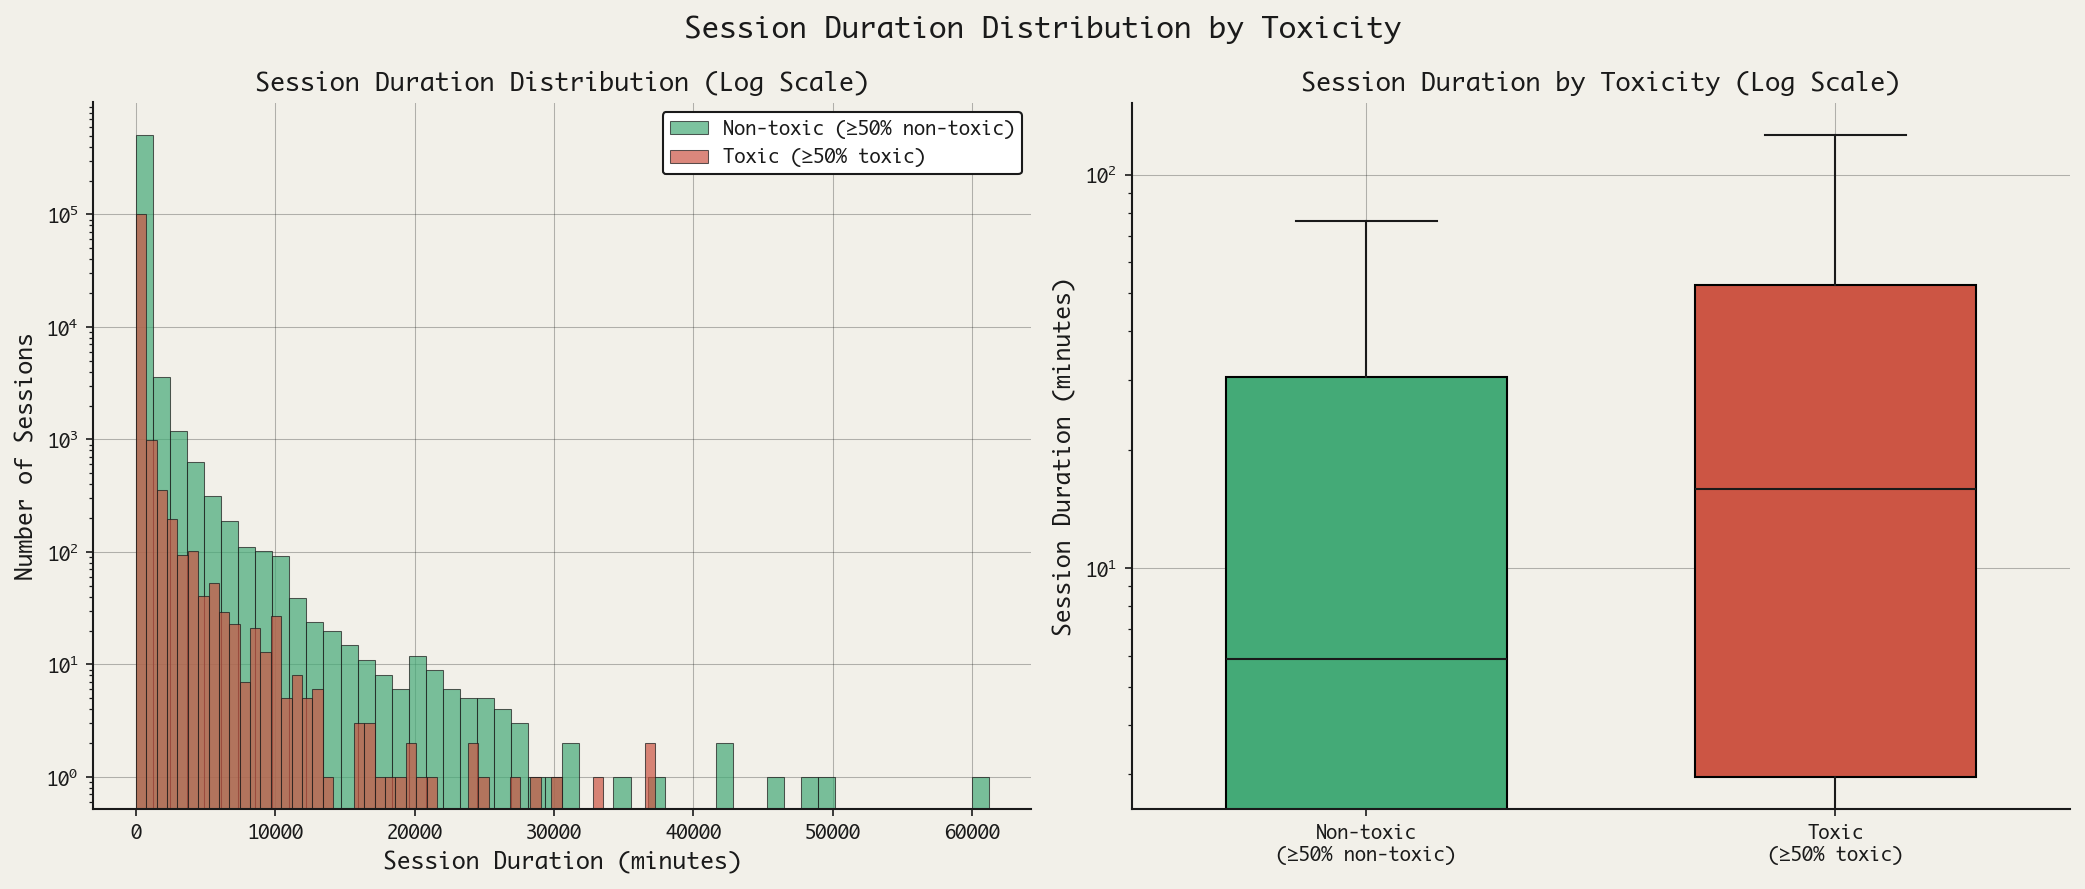


Statistical comparison:
  Non-toxic sessions (n=518,649):
    Mean: 76.52 minutes
    Median: 5.88 minutes
  Toxic sessions (n=103,940):
    Mean: 96.43 minutes
    Median: 15.93 minutes

  Mann-Whitney U test:
    U-statistic: 21,103,360,623
    p-value: 0.00e+00
    *** Significant difference (p < 0.001) ***

INTER-SESSION GAP STATISTICS

Inter-session gap statistics (n=398,682 valid gaps):
  Mean time difference between sessions: 3512.03 minutes
  Median time difference between sessions: 552.34 minutes
  Min gap: 0.02 minutes
  Max gap: 774689.07 minutes

Saved session metrics to: ../outputs/data/session_metrics.parquet

Analysis complete.


In [13]:
# ============================================================
# Visualization and Summary Statistics
# ============================================================

print("="*70)
print("VISUALIZATION AND SUMMARY")
print("="*70)

# ============================================================
# Calculate Additional Session Metrics for Concerning Use Detection
# ============================================================

print("\nCalculating additional session metrics for concerning use detection...")

# Recalculate gaps between conversations within sessions if not already present
# Sort by session and conversation start to calculate gaps correctly
final_df_sorted = final_df.sort(['unique_session_id', 'conversation_start'])

# Calculate gaps between consecutive conversations within each session
final_df_with_gaps = final_df_sorted.with_columns([
    pl.col('conversation_end').shift(1).over('unique_session_id').alias('prev_conversation_end')
]).with_columns([
    # Calculate gap in minutes (only for conversations after the first in each session)
    pl.when(pl.col('prev_conversation_end').is_not_null())
    .then((pl.col('conversation_start') - pl.col('prev_conversation_end')).dt.total_seconds() / 60.0)
    .otherwise(0.0)
    .alias('gap_minutes')
])

# Calculate total turns per session by summing n_turns from conversations
# Also calculate max internal gap within each session
session_metrics = final_df_with_gaps.group_by('unique_session_id').agg([
    pl.col('n_turns').sum().alias('total_turns'),
    pl.col('gap_minutes').max().alias('max_internal_gap_minutes'),
])

# Join with session_df
session_df = session_df.join(session_metrics, on='unique_session_id', how='left')

# Calculate additional derived metrics
session_df = session_df.with_columns([
    (pl.col('session_duration_minutes') / 60.0).alias('span_hours'),
    (pl.col('total_turns') / (pl.col('session_duration_minutes') / 60.0)).alias('turns_per_hour'),
])

# Handle edge cases where session_duration_minutes is 0 or very small
session_df = session_df.with_columns([
    pl.when(pl.col('session_duration_minutes') <= 0)
    .then(None)
    .otherwise(pl.col('turns_per_hour'))
    .alias('turns_per_hour'),
])

# For max_internal_gap_minutes, if there's only one conversation in the session,
# set it to 0 (no internal gaps)
session_df = session_df.with_columns([
    pl.when(pl.col('n_conversations') == 1)
    .then(0.0)
    .otherwise(pl.col('max_internal_gap_minutes'))
    .alias('max_internal_gap_minutes'),
])

print(f"  Calculated metrics for {len(session_df):,} sessions")

# ============================================================
# DEFINITION: Potentially Concerning Session
# ============================================================
# 
# A session is "potentially concerning" if ALL of:
# 1. Span > 6 hours (elapsed time)
# 2. Turn density > 2 turns/hour (active engagement, not idle)
# 3. Max gap within session < 60 minutes (sustained, not "left tab open")
# 4. Total turns > 30 (substantial interaction)

def is_concerning_session(session):
    """Check if a session meets all criteria for potentially concerning use."""
    # Handle None values (e.g., when session duration is 0)
    span_hours = session.get('span_hours')
    turns_per_hour = session.get('turns_per_hour')
    max_internal_gap_minutes = session.get('max_internal_gap_minutes')
    total_turns = session.get('total_turns')
    
    # If any required value is None, session is not concerning
    if span_hours is None or turns_per_hour is None or max_internal_gap_minutes is None or total_turns is None:
        return False
    
    return (
        span_hours > 6 and
        turns_per_hour >= 2 and
        max_internal_gap_minutes < 60 and
        total_turns >= 30
    )

# Apply the function to identify concerning sessions
# Convert session_df rows to dictionaries for the function
concerning_flags = []
for row in session_df.iter_rows(named=True):
    concerning_flags.append(is_concerning_session(row))

session_df = session_df.with_columns([
    pl.Series('is_concerning_session', concerning_flags, dtype=pl.Boolean)
])

n_concerning = session_df['is_concerning_session'].sum()
print(f"\nIdentified {n_concerning:,} potentially concerning sessions ({100*n_concerning/len(session_df):.2f}% of all sessions)")

# ============================================================
# Summary Statistics for Concerning Sessions
# ============================================================

if n_concerning > 0:
    concerning_sessions = session_df.filter(pl.col('is_concerning_session') == True)
    print(f"\nConcerning session statistics:")
    print(f"  Mean span: {concerning_sessions['span_hours'].mean():.2f} hours")
    print(f"  Median span: {concerning_sessions['span_hours'].median():.2f} hours")
    print(f"  Mean turns per hour: {concerning_sessions['turns_per_hour'].mean():.2f}")
    print(f"  Median turns per hour: {concerning_sessions['turns_per_hour'].median():.2f}")
    print(f"  Mean total turns: {concerning_sessions['total_turns'].mean():.1f}")
    print(f"  Median total turns: {concerning_sessions['total_turns'].median():.0f}")
    print(f"  Mean max internal gap: {concerning_sessions['max_internal_gap_minutes'].mean():.2f} minutes")
    print(f"  Median max internal gap: {concerning_sessions['max_internal_gap_minutes'].median():.2f} minutes")
    
    # Count unique users with concerning sessions
    users_with_concerning = concerning_sessions['user_id'].n_unique()
    print(f"\n  Users with >=1 concerning session: {users_with_concerning:,}")

print("\n" + "="*70)

# Create histogram of session duration grouped by toxicity
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Session Duration Distribution by Toxicity', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Histogram
ax = axes[0]
toxic_sessions = session_df.filter(pl.col('is_toxic_session') == True)['session_duration_minutes'].to_numpy()
non_toxic_sessions = session_df.filter(pl.col('is_toxic_session') == False)['session_duration_minutes'].to_numpy()

# Use log scale for better visualization (many short sessions)
ax.hist(non_toxic_sessions, bins=50, alpha=0.7, label='Non-toxic (≥50% non-toxic)', 
        color=BRAND['success'], edgecolor=BRAND['ink'], linewidth=0.5)
ax.hist(toxic_sessions, bins=50, alpha=0.7, label='Toxic (≥50% toxic)', 
        color=BRAND['alert'], edgecolor=BRAND['ink'], linewidth=0.5)

ax.set_xlabel('Session Duration (minutes)', fontsize=11, color=BRAND['ink'])
ax.set_ylabel('Number of Sessions', fontsize=11, color=BRAND['ink'])
ax.set_yscale('log')
ax.set_title('Session Duration Distribution (Log Scale)', fontsize=12, fontweight='bold', color=BRAND['ink'])
ax.legend(fontsize=9, framealpha=1.0, facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

# Panel 2: Box plot comparison
ax = axes[1]
box_data = [non_toxic_sessions, toxic_sessions]
box_labels = ['Non-toxic\n(≥50% non-toxic)', 'Toxic\n(≥50% toxic)']
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, 
                widths=0.6, showfliers=False)

# Color the boxes
bp['boxes'][0].set_facecolor(BRAND['success'])
bp['boxes'][1].set_facecolor(BRAND['alert'])
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    if element in bp:
        for item in bp[element]:
            item.set_color(BRAND['ink'])

ax.set_ylabel('Session Duration (minutes)', fontsize=11, color=BRAND['ink'])
ax.set_yscale('log')
ax.set_title('Session Duration by Toxicity (Log Scale)', fontsize=12, fontweight='bold', color=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'session_duration_by_toxicity')
plt.show()

# Statistical comparison
print("\nStatistical comparison:")
print(f"  Non-toxic sessions (n={len(non_toxic_sessions):,}):")
print(f"    Mean: {np.mean(non_toxic_sessions):.2f} minutes")
print(f"    Median: {np.median(non_toxic_sessions):.2f} minutes")
print(f"  Toxic sessions (n={len(toxic_sessions):,}):")
print(f"    Mean: {np.mean(toxic_sessions):.2f} minutes")
print(f"    Median: {np.median(toxic_sessions):.2f} minutes")

# Mann-Whitney U test (non-parametric, handles skewed distributions)
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(non_toxic_sessions, toxic_sessions, alternative='two-sided')
print(f"\n  Mann-Whitney U test:")
print(f"    U-statistic: {statistic:,.0f}")
print(f"    p-value: {p_value:.2e}")

if p_value < 0.001:
    print("    *** Significant difference (p < 0.001) ***")
elif p_value < 0.01:
    print("    ** Significant difference (p < 0.01) **")
elif p_value < 0.05:
    print("    * Significant difference (p < 0.05) *")
else:
    print("    No significant difference")

# Inter-session gap statistics
print("\n" + "="*70)
print("INTER-SESSION GAP STATISTICS")
print("="*70)

# Recalculate inter-session gaps if not already calculated (e.g., after kernel restart)
if 'inter_session_gaps' not in globals() or len(inter_session_gaps) == 0:
    print("Calculating inter-session gaps...")
    inter_session_gaps = []
    
    for user_id in session_df['user_id'].unique().to_list():
        user_sessions = session_df.filter(pl.col('user_id') == user_id).sort('session_start')
        
        # Only calculate gaps for users with 2+ sessions
        if len(user_sessions) >= 2:
            for i in range(len(user_sessions) - 1):
                prev_end = user_sessions['session_end'][i]
                curr_start = user_sessions['session_start'][i + 1]
                
                # Calculate gap in minutes
                gap_minutes = (curr_start - prev_end).total_seconds() / 60.0
                # Only include positive gaps (filter out overlapping sessions)
                if gap_minutes > 0:
                    inter_session_gaps.append(gap_minutes)

if len(inter_session_gaps) > 0:
    mean_gap = np.mean(inter_session_gaps)
    median_gap = np.median(inter_session_gaps)
    print(f"\nInter-session gap statistics (n={len(inter_session_gaps):,} valid gaps):")
    print(f"  Mean time difference between sessions: {mean_gap:.2f} minutes")
    print(f"  Median time difference between sessions: {median_gap:.2f} minutes")
    print(f"  Min gap: {np.min(inter_session_gaps):.2f} minutes")
    print(f"  Max gap: {np.max(inter_session_gaps):.2f} minutes")
else:
    print("\nNo inter-session gaps to report (all users have only 1 session)")

# Save session dataframe
output_path = '../outputs/data/session_metrics.parquet'
session_df.write_parquet(output_path)
print(f"\nSaved session metrics to: {output_path}")

print("\n" + "="*70)
print("Analysis complete.")
print("="*70)


---

## Concerning Sessions Deep Dive Analysis

This section provides a comprehensive analysis of "potentially concerning" sessions identified in the previous analysis. These are sessions that meet all of the following criteria:
- Session span > 6 hours
- Turn density ≥ 2 turns/hour (active engagement, not idle)
- Max internal gap < 60 minutes (sustained, not interrupted)
- Total turns ≥ 30 (substantial interaction)

**Key Research Questions:**
1. What are they doing? (Intent/topic distribution)
2. Is toxicity involved? (Toxicity ratio, overlap with toxic sessions)
3. When does it happen? (Time of day, day of week, late night ratio)
4. One-time or repeat? (Sessions per user distribution)
5. When does it emerge? (Session number of first concerning session)
6. How do they differ? (Matched control comparison)


In [14]:
# ============================================================
# DATA LOADING FOR CONCERNING SESSIONS ANALYSIS
# ============================================================

print("="*70)
print("DATA LOADING FOR CONCERNING SESSIONS ANALYSIS")
print("="*70)

# Load session metrics (use existing session_df if available, otherwise load from file)
if 'session_df' not in globals() or session_df is None:
    print("Loading session metrics from file...")
    session_metrics = pl.read_parquet('../outputs/data/session_metrics.parquet')
else:
    print("Using existing session_df...")
    session_metrics = session_df

print(f"Total sessions: {len(session_metrics):,}")

# Load turn-level data for content analysis
# We need to reconstruct turn_df with session_id mapping
print("\nReconstructing turn-level data with session mapping...")

# Get conversation hashes from final_df and map to sessions
if 'final_df' in globals() and final_df is not None:
    conv_to_session = final_df.select(['conversation_hash', 'unique_session_id']).unique()
    
    # Join turn_df with session mapping
    if 'turn_df' in globals() and turn_df is not None:
        turn_df = turn_df.join(conv_to_session, on='conversation_hash', how='left')
        print(f"Turn-level data with session mapping: {len(turn_df):,} turns")
    else:
        print("Warning: turn_df not available. Some analyses will be skipped.")
        turn_df = None
else:
    print("Warning: final_df not available. Some analyses will be skipped.")
    turn_df = None

# Identify concerning sessions
concerning_sessions = session_metrics.filter(
    (pl.col('span_hours') > 6) &
    (pl.col('turns_per_hour') >= 2) &
    (pl.col('max_internal_gap_minutes') < 60) &
    (pl.col('total_turns') >= 30)
)

print(f"\nConcerning sessions: {len(concerning_sessions):,} ({100*len(concerning_sessions)/len(session_metrics):.2f}%)")

# Non-concerning sessions for comparison
normal_sessions = session_metrics.filter(
    ~pl.col('unique_session_id').is_in(concerning_sessions['unique_session_id'])
)

print(f"Normal sessions: {len(normal_sessions):,}")

# Users with concerning sessions
concerning_user_ids = concerning_sessions['user_id'].unique().to_list()
print(f"Users with ≥1 concerning session: {len(concerning_user_ids):,}")

# Add toxicity flag if not present
if 'is_toxic' not in concerning_sessions.columns:
    concerning_sessions = concerning_sessions.with_columns([
        (pl.col('session_toxicity_ratio') >= 0.5).alias('is_toxic')
    ])
if 'is_toxic' not in normal_sessions.columns:
    normal_sessions = normal_sessions.with_columns([
        (pl.col('session_toxicity_ratio') >= 0.5).alias('is_toxic')
    ])

# Add toxicity_ratio if not present (use session_toxicity_ratio)
if 'session_toxicity_ratio' not in concerning_sessions.columns:
    concerning_sessions = concerning_sessions.with_columns([
        pl.col('session_toxicity_ratio').alias('toxicity_ratio')
    ])
if 'session_toxicity_ratio' not in normal_sessions.columns:
    normal_sessions = normal_sessions.with_columns([
        pl.col('session_toxicity_ratio').alias('toxicity_ratio')
    ])

print("\n" + "="*70)
print("Data loading complete.")
print("="*70)


DATA LOADING FOR CONCERNING SESSIONS ANALYSIS
Using existing session_df...
Total sessions: 622,589

Reconstructing turn-level data with session mapping...
Turn-level data with session mapping: 5,751,441 turns

Concerning sessions: 2,259 (0.36%)
Normal sessions: 620,330
Users with ≥1 concerning session: 1,537

Data loading complete.


ANALYSIS 1: TOXICITY OVERLAP
Toxicity in Concerning Sessions:
  Sessions with any toxic content: 41.6%
  Sessions >50% toxic: 35.4%
  Sessions 100% toxic: 22.1%
  Mean toxicity ratio: 0.403

Baseline (Normal Sessions):
  Sessions with any toxic content: 16.6%
  Sessions >50% toxic: 13.9%
  Mean toxicity ratio: 0.157

Mann-Whitney U test: p = 0.00e+00

High-concern subset (long + >50% toxic): 800
  Percentage of concerning sessions: 35.4%
  Unique users: 536
Saved: ../outputs/figures/pub_concerning_toxicity_analysis.png


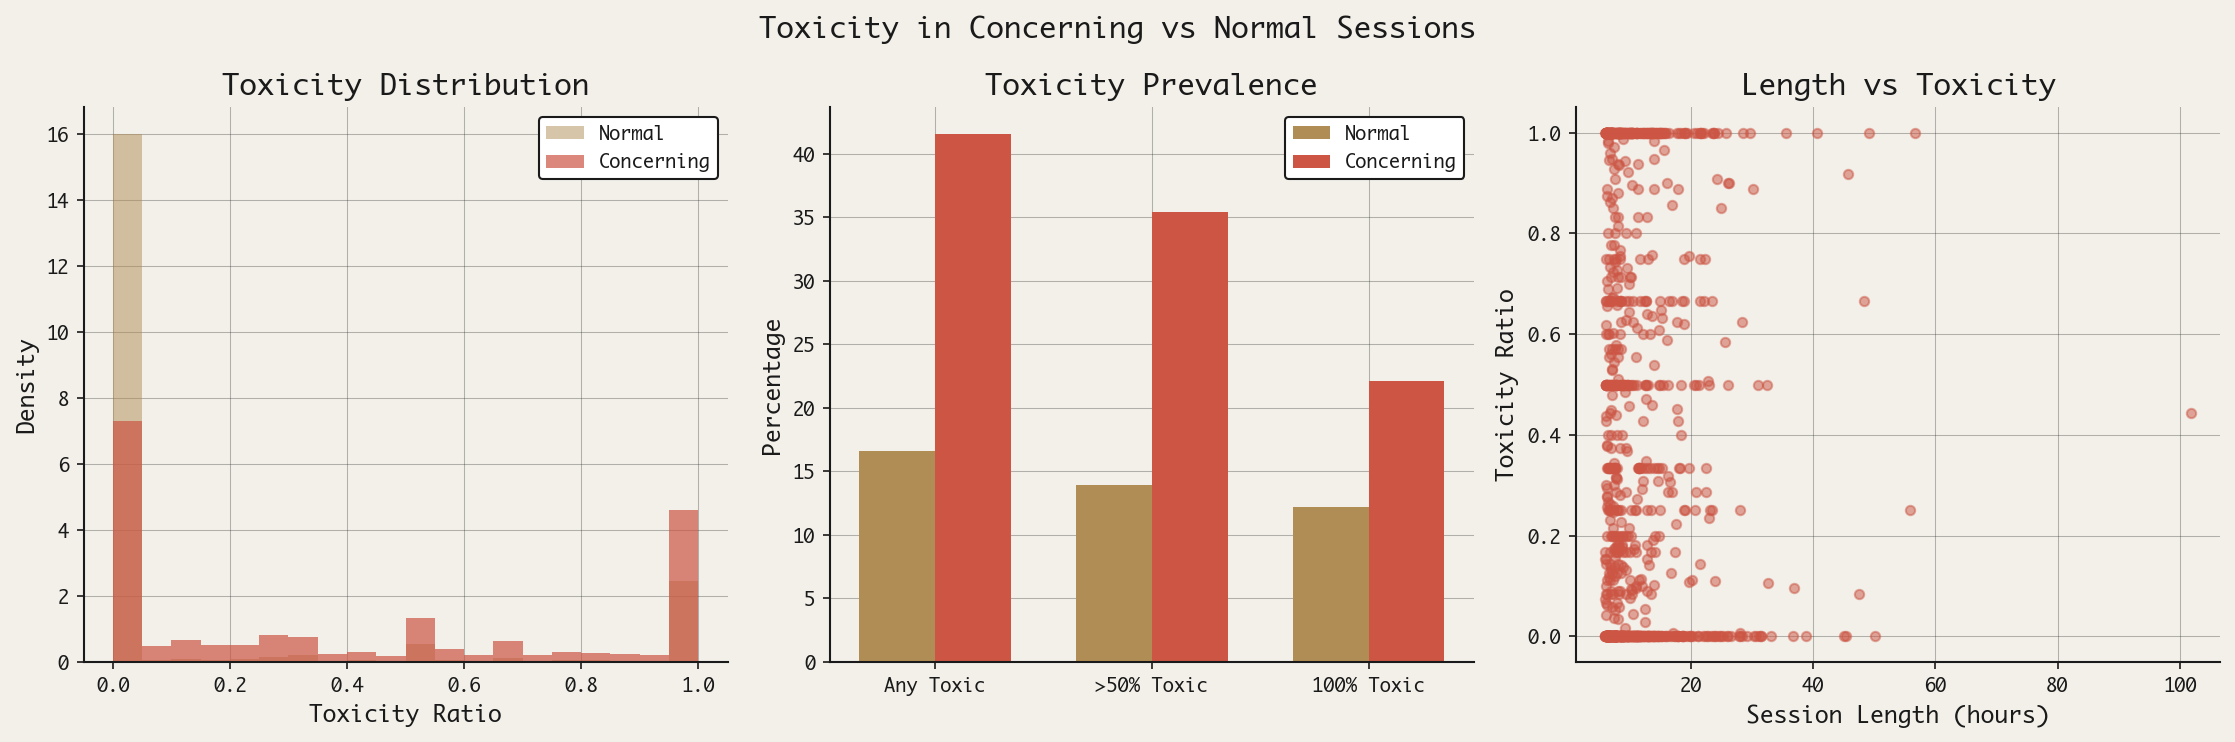

In [15]:
# ============================================================
# ANALYSIS 1: TOXICITY IN CONCERNING SESSIONS
# ============================================================

print("="*70)
print("ANALYSIS 1: TOXICITY OVERLAP")
print("="*70)

# Toxicity statistics
print("Toxicity in Concerning Sessions:")
print(f"  Sessions with any toxic content: {concerning_sessions['is_toxic'].mean():.1%}")
print(f"  Sessions >50% toxic: {(concerning_sessions['session_toxicity_ratio'] > 0.5).mean():.1%}")
print(f"  Sessions 100% toxic: {(concerning_sessions['session_toxicity_ratio'] == 1.0).mean():.1%}")
print(f"  Mean toxicity ratio: {concerning_sessions['session_toxicity_ratio'].mean():.3f}")

print("\nBaseline (Normal Sessions):")
print(f"  Sessions with any toxic content: {normal_sessions['is_toxic'].mean():.1%}")
print(f"  Sessions >50% toxic: {(normal_sessions['session_toxicity_ratio'] > 0.5).mean():.1%}")
print(f"  Mean toxicity ratio: {normal_sessions['session_toxicity_ratio'].mean():.3f}")

# Statistical test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(
    concerning_sessions['session_toxicity_ratio'].to_numpy(),
    normal_sessions['session_toxicity_ratio'].to_numpy(),
    alternative='two-sided'
)
print(f"\nMann-Whitney U test: p = {p:.2e}")

# Identify high-concern subset: Long AND Toxic
long_and_toxic = concerning_sessions.filter(pl.col('session_toxicity_ratio') > 0.5)
print(f"\nHigh-concern subset (long + >50% toxic): {len(long_and_toxic):,}")
print(f"  Percentage of concerning sessions: {100*len(long_and_toxic)/len(concerning_sessions):.1f}%")
print(f"  Unique users: {long_and_toxic['user_id'].n_unique():,}")

# Visualization: Toxicity distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Toxicity in Concerning vs Normal Sessions', fontsize=14, fontweight='bold')

# Panel 1: Toxicity ratio distribution
ax = axes[0]
ax.hist(normal_sessions['session_toxicity_ratio'].to_numpy(), bins=20, alpha=0.5, 
        density=True, label='Normal', color=BRAND['gold'])
ax.hist(concerning_sessions['session_toxicity_ratio'].to_numpy(), bins=20, alpha=0.7, 
        density=True, label='Concerning', color=BRAND['alert'])
ax.set_xlabel('Toxicity Ratio')
ax.set_ylabel('Density')
ax.set_title('Toxicity Distribution')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Binary comparison
ax = axes[1]
categories = ['Any Toxic', '>50% Toxic', '100% Toxic']
normal_rates = [
    normal_sessions['is_toxic'].mean() * 100,
    (normal_sessions['session_toxicity_ratio'] > 0.5).mean() * 100,
    (normal_sessions['session_toxicity_ratio'] == 1.0).mean() * 100,
]
concerning_rates = [
    concerning_sessions['is_toxic'].mean() * 100,
    (concerning_sessions['session_toxicity_ratio'] > 0.5).mean() * 100,
    (concerning_sessions['session_toxicity_ratio'] == 1.0).mean() * 100,
]

x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, normal_rates, width, label='Normal', color=BRAND['gold'])
ax.bar(x + width/2, concerning_rates, width, label='Concerning', color=BRAND['alert'])
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Percentage')
ax.set_title('Toxicity Prevalence')
ax.legend()
apply_phronos_style(ax)

# Panel 3: Session length vs toxicity scatter
ax = axes[2]
# Sample for visualization
sample_concerning = concerning_sessions.sample(min(1000, len(concerning_sessions)), seed=RANDOM_STATE)
ax.scatter(sample_concerning['span_hours'].to_numpy(),
           sample_concerning['session_toxicity_ratio'].to_numpy(),
           alpha=0.5, s=20, color=BRAND['alert'])
ax.set_xlabel('Session Length (hours)')
ax.set_ylabel('Toxicity Ratio')
ax.set_title('Length vs Toxicity')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'concerning_toxicity_analysis')
plt.show()


ANALYSIS 2: WHEN DO CONCERNING SESSIONS OCCUR?
Temporal Comparison:
  Late night (0-5am) - Concerning: 25.3%, Normal: 21.0%
  Weekend - Concerning: 41.2%, Normal: 38.3%

Late night chi-square: χ² = 24.1, p = 9.17e-07
Weekend chi-square: χ² = 8.2, p = 4.27e-03
Saved: ../outputs/figures/pub_concerning_temporal_patterns.png


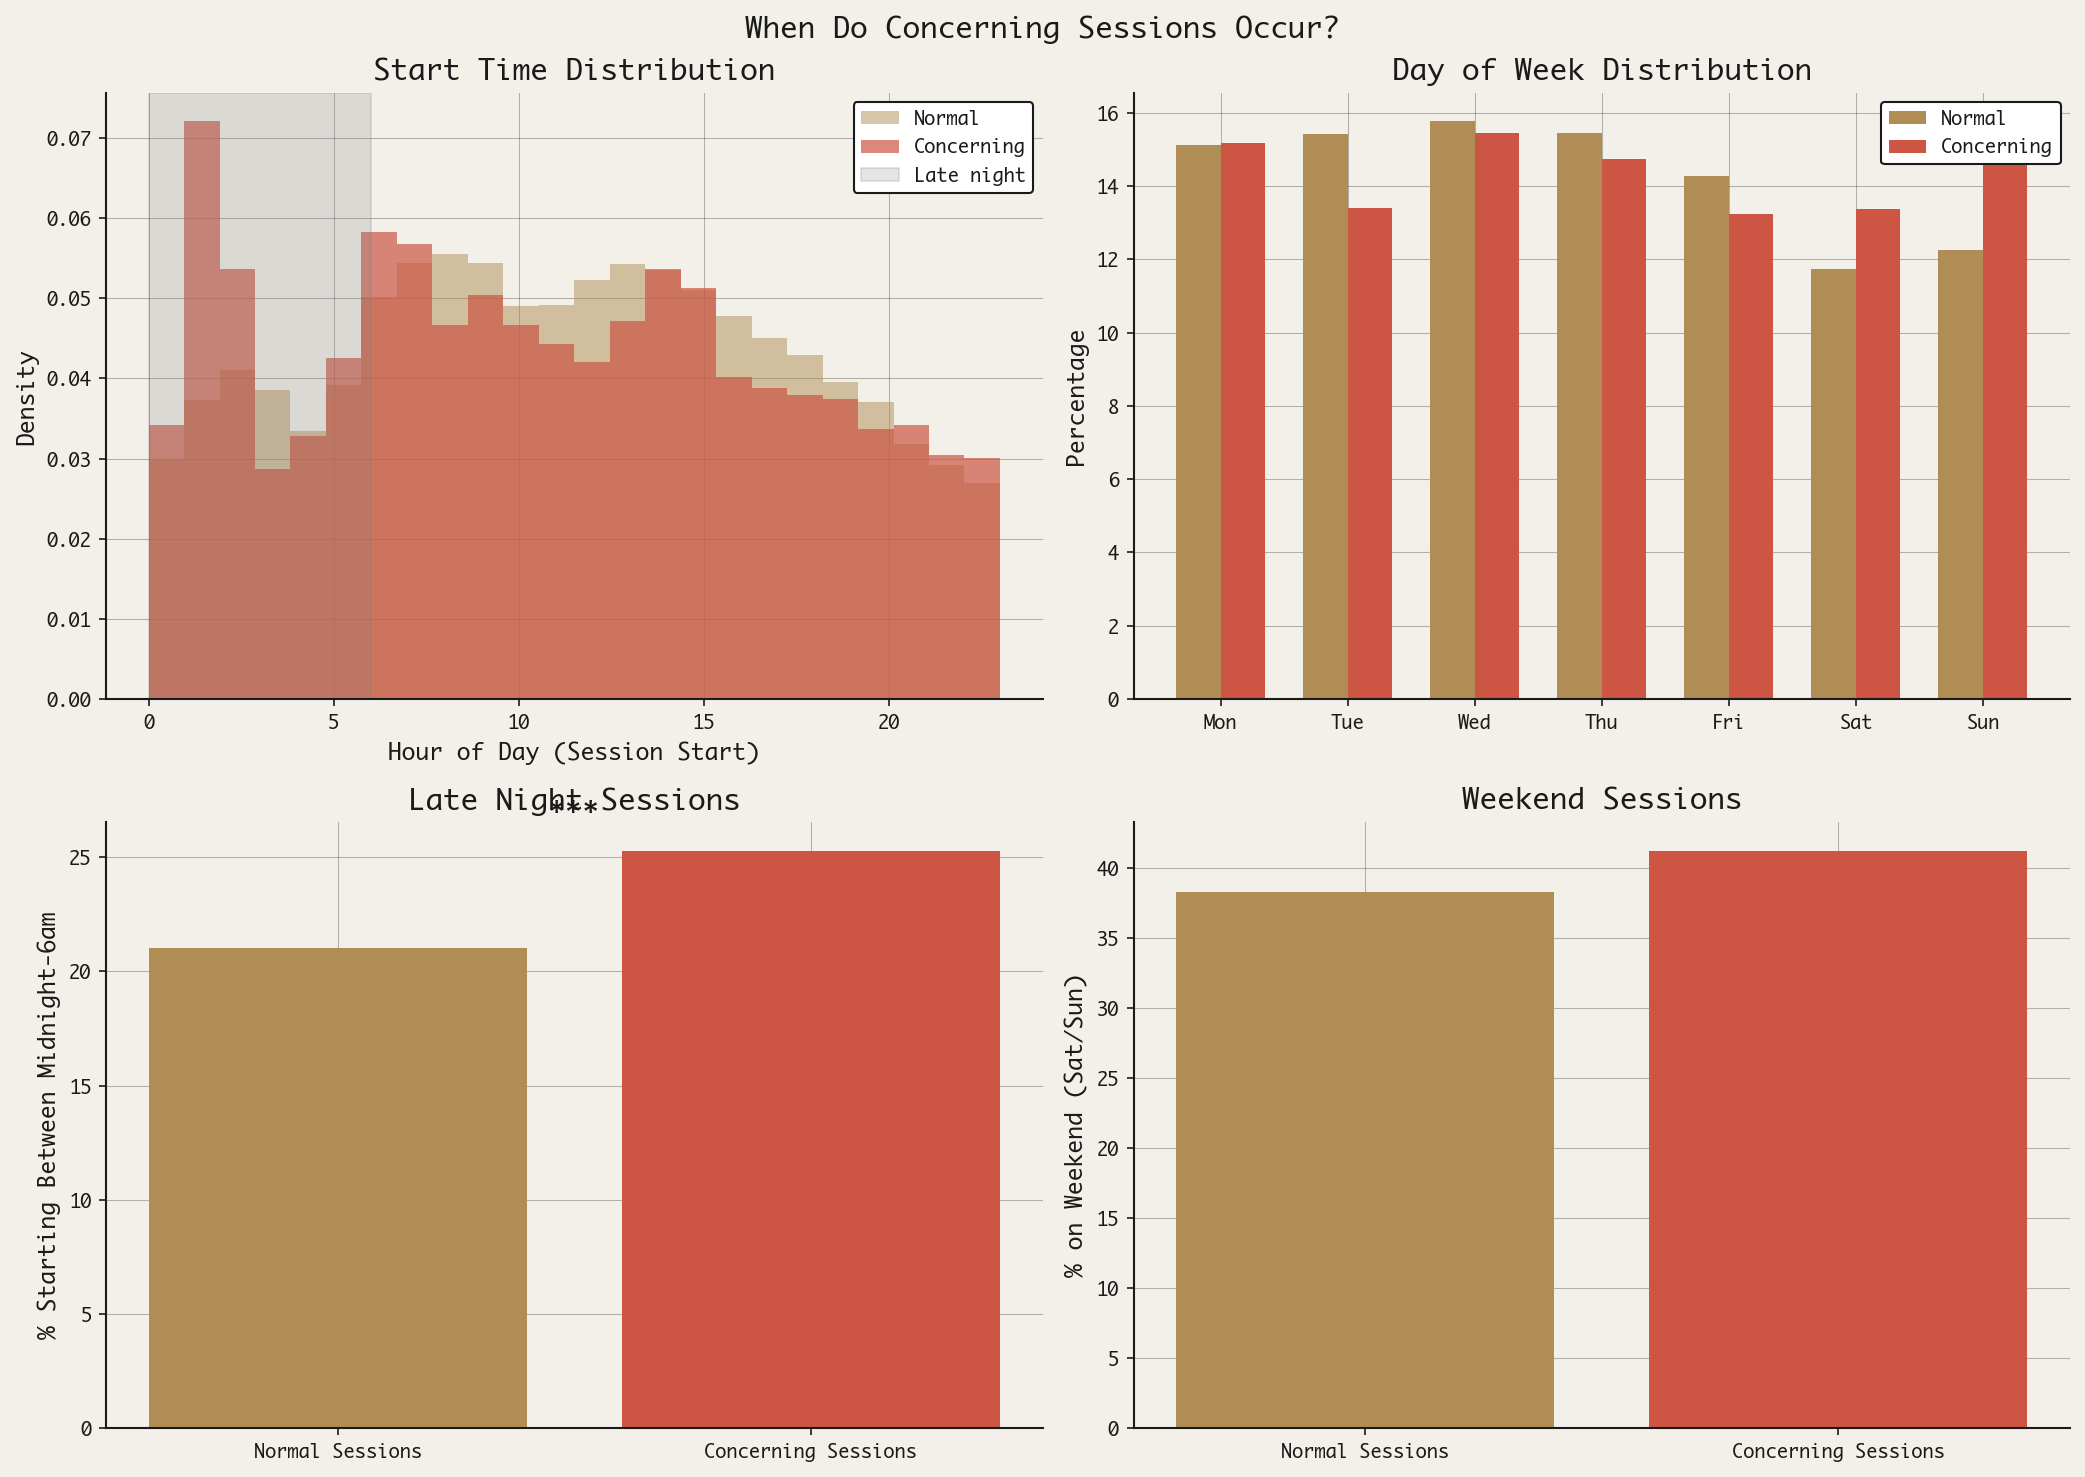

In [16]:
# ============================================================
# ANALYSIS 2: TEMPORAL PATTERNS
# ============================================================

print("="*70)
print("ANALYSIS 2: WHEN DO CONCERNING SESSIONS OCCUR?")
print("="*70)

# Extract temporal features
concerning_sessions = concerning_sessions.with_columns([
    pl.col('session_start').dt.hour().alias('start_hour'),
    pl.col('session_start').dt.weekday().alias('day_of_week'),  # 0=Monday
    (pl.col('session_start').dt.hour().is_between(0, 5)).alias('is_late_night'),
    (pl.col('session_start').dt.weekday() >= 5).alias('is_weekend'),
])

normal_sessions = normal_sessions.with_columns([
    pl.col('session_start').dt.hour().alias('start_hour'),
    pl.col('session_start').dt.weekday().alias('day_of_week'),
    (pl.col('session_start').dt.hour().is_between(0, 5)).alias('is_late_night'),
    (pl.col('session_start').dt.weekday() >= 5).alias('is_weekend'),
])

# Statistics
print("Temporal Comparison:")
print(f"  Late night (0-5am) - Concerning: {concerning_sessions['is_late_night'].mean():.1%}, "
      f"Normal: {normal_sessions['is_late_night'].mean():.1%}")
print(f"  Weekend - Concerning: {concerning_sessions['is_weekend'].mean():.1%}, "
      f"Normal: {normal_sessions['is_weekend'].mean():.1%}")

# Chi-square tests
from scipy.stats import chi2_contingency
contingency_late = [
    [concerning_sessions['is_late_night'].sum(), (~concerning_sessions['is_late_night']).sum()],
    [normal_sessions['is_late_night'].sum(), (~normal_sessions['is_late_night']).sum()]
]
chi2, p_late, _, _ = chi2_contingency(contingency_late)
print(f"\nLate night chi-square: χ² = {chi2:.1f}, p = {p_late:.2e}")

contingency_weekend = [
    [concerning_sessions['is_weekend'].sum(), (~concerning_sessions['is_weekend']).sum()],
    [normal_sessions['is_weekend'].sum(), (~normal_sessions['is_weekend']).sum()]
]
chi2, p_weekend, _, _ = chi2_contingency(contingency_weekend)
print(f"Weekend chi-square: χ² = {chi2:.1f}, p = {p_weekend:.2e}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('When Do Concerning Sessions Occur?', fontsize=14, fontweight='bold')

# Panel 1: Hour of day
ax = axes[0, 0]
concerning_hours = concerning_sessions['start_hour'].to_numpy()
normal_hours = normal_sessions['start_hour'].to_numpy()

ax.hist(normal_hours, bins=24, alpha=0.5, density=True, label='Normal', color=BRAND['gold'])
ax.hist(concerning_hours, bins=24, alpha=0.7, density=True, label='Concerning', color=BRAND['alert'])
ax.axvspan(0, 6, alpha=0.2, color='gray', label='Late night')
ax.set_xlabel('Hour of Day (Session Start)')
ax.set_ylabel('Density')
ax.set_title('Start Time Distribution')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Day of week
ax = axes[0, 1]
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

concerning_dow = concerning_sessions.group_by('day_of_week').len().sort('day_of_week')
normal_dow = normal_sessions.group_by('day_of_week').len().sort('day_of_week')

concerning_dow_pct = concerning_dow['len'].to_numpy() / concerning_dow['len'].sum()
normal_dow_pct = normal_dow['len'].to_numpy() / normal_dow['len'].sum()

x = np.arange(7)
width = 0.35
ax.bar(x - width/2, normal_dow_pct * 100, width, label='Normal', color=BRAND['gold'])
ax.bar(x + width/2, concerning_dow_pct * 100, width, label='Concerning', color=BRAND['alert'])
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_ylabel('Percentage')
ax.set_title('Day of Week Distribution')
ax.legend()
apply_phronos_style(ax)

# Panel 3: Late night comparison
ax = axes[1, 0]
categories = ['Normal Sessions', 'Concerning Sessions']
late_night_rates = [
    normal_sessions['is_late_night'].mean() * 100,
    concerning_sessions['is_late_night'].mean() * 100,
]
colors = [BRAND['gold'], BRAND['alert']]
ax.bar(categories, late_night_rates, color=colors)
ax.set_ylabel('% Starting Between Midnight-6am')
ax.set_title('Late Night Sessions')

# Add significance annotation
if p_late < 0.001:
    ax.annotate('***', xy=(0.5, max(late_night_rates) * 1.05), ha='center', fontsize=14)
apply_phronos_style(ax)

# Panel 4: Weekend comparison
ax = axes[1, 1]
weekend_rates = [
    normal_sessions['is_weekend'].mean() * 100,
    concerning_sessions['is_weekend'].mean() * 100,
]
ax.bar(categories, weekend_rates, color=colors)
ax.set_ylabel('% on Weekend (Sat/Sun)')
ax.set_title('Weekend Sessions')

if p_weekend < 0.001:
    ax.annotate('***', xy=(0.5, max(weekend_rates) * 1.05), ha='center', fontsize=14)
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'concerning_temporal_patterns')
plt.show()


ANALYSIS 3: ONE-TIME VS REPEAT USERS
Concerning Sessions per User:
  Users with exactly 1: 1,263 (82.2%)
  Users with 2: 162
  Users with 3-5: 79
  Users with 6-10: 20
  Users with 10+: 13
  Maximum: 38

'Repeat' users (3+ concerning sessions): 112
'One-time' users (exactly 1): 1,263

Repeat vs One-time Session Characteristics:
  Mean span (hours) - Repeat: 11.7, One-time: 11.0
  Mean toxicity - Repeat: 0.494, One-time: 0.364
  Mean turns/hour - Repeat: 13.0, One-time: 11.9
  Late night % - Repeat: 24.6%, One-time: 25.0%
Saved: ../outputs/figures/pub_concerning_repeat_patterns.png


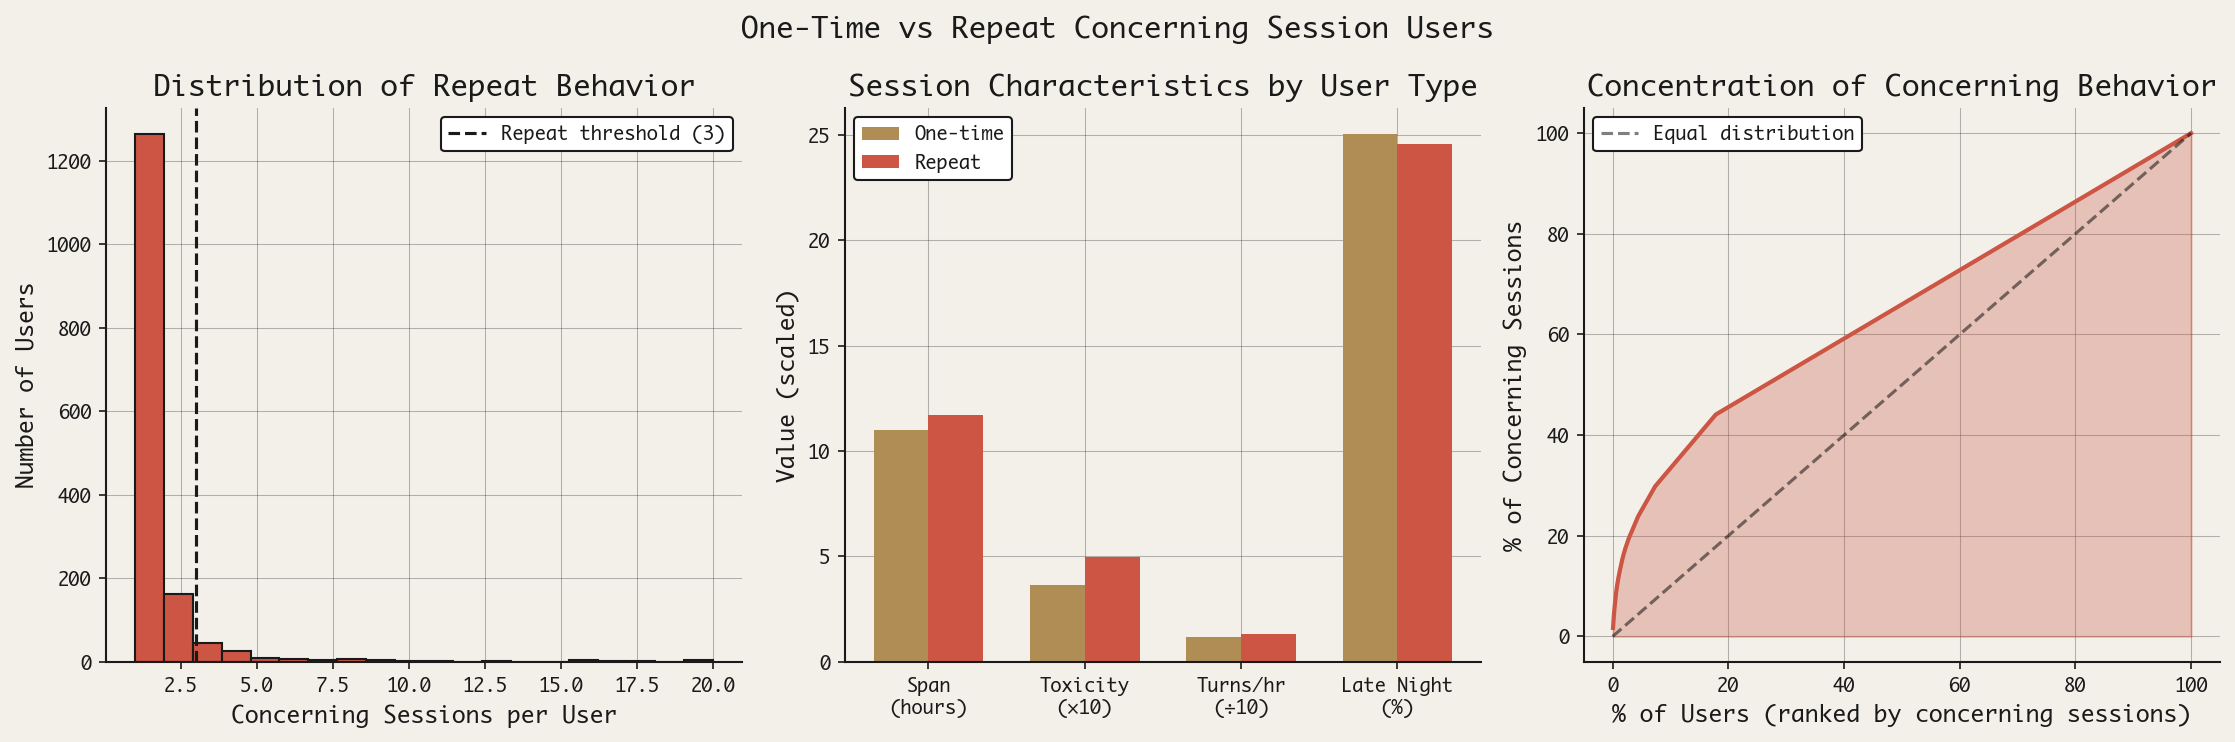


Concentration (Gini coefficient): -0.291
  0 = perfectly equal, 1 = one user has all


In [18]:
# ============================================================
# ANALYSIS 3: USER PERSISTENCE PATTERNS
# ============================================================

print("="*70)
print("ANALYSIS 3: ONE-TIME VS REPEAT USERS")
print("="*70)

# Count concerning sessions per user
user_concerning_counts = concerning_sessions.group_by('user_id').agg([
    pl.len().alias('n_concerning'),
    pl.col('span_hours').mean().alias('mean_span'),
    pl.col('session_toxicity_ratio').mean().alias('mean_toxicity'),
    pl.col('total_turns').sum().alias('total_concerning_turns'),
])

print("Concerning Sessions per User:")
print(f"  Users with exactly 1: {(user_concerning_counts['n_concerning'] == 1).sum():,} "
      f"({(user_concerning_counts['n_concerning'] == 1).mean():.1%})")
print(f"  Users with 2: {(user_concerning_counts['n_concerning'] == 2).sum():,}")
print(f"  Users with 3-5: {((user_concerning_counts['n_concerning'] >= 3) & (user_concerning_counts['n_concerning'] <= 5)).sum():,}")
print(f"  Users with 6-10: {((user_concerning_counts['n_concerning'] >= 6) & (user_concerning_counts['n_concerning'] <= 10)).sum():,}")
print(f"  Users with 10+: {(user_concerning_counts['n_concerning'] > 10).sum():,}")
print(f"  Maximum: {user_concerning_counts['n_concerning'].max()}")

# Define repeat users (3+ concerning sessions)
REPEAT_THRESHOLD = 3
repeat_users = user_concerning_counts.filter(
    pl.col('n_concerning') >= REPEAT_THRESHOLD
)['user_id'].to_list()

onetime_users = user_concerning_counts.filter(
    pl.col('n_concerning') == 1
)['user_id'].to_list()

print(f"\n'Repeat' users ({REPEAT_THRESHOLD}+ concerning sessions): {len(repeat_users):,}")
print(f"'One-time' users (exactly 1): {len(onetime_users):,}")

# Compare repeat vs one-time users
repeat_sessions = concerning_sessions.filter(pl.col('user_id').is_in(repeat_users))
onetime_sessions = concerning_sessions.filter(pl.col('user_id').is_in(onetime_users))

print(f"\nRepeat vs One-time Session Characteristics:")
print(f"  Mean span (hours) - Repeat: {repeat_sessions['span_hours'].mean():.1f}, "
      f"One-time: {onetime_sessions['span_hours'].mean():.1f}")
print(f"  Mean toxicity - Repeat: {repeat_sessions['session_toxicity_ratio'].mean():.3f}, "
      f"One-time: {onetime_sessions['session_toxicity_ratio'].mean():.3f}")
print(f"  Mean turns/hour - Repeat: {repeat_sessions['turns_per_hour'].mean():.1f}, "
      f"One-time: {onetime_sessions['turns_per_hour'].mean():.1f}")
print(f"  Late night % - Repeat: {repeat_sessions['is_late_night'].mean():.1%}, "
      f"One-time: {onetime_sessions['is_late_night'].mean():.1%}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('One-Time vs Repeat Concerning Session Users', fontsize=14, fontweight='bold')

# Panel 1: Sessions per user distribution
ax = axes[0]
ax.hist(user_concerning_counts['n_concerning'].clip(None, 20).to_numpy(), 
        bins=20, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvline(x=REPEAT_THRESHOLD, color=BRAND['ink'], linestyle='--', 
           label=f'Repeat threshold ({REPEAT_THRESHOLD})')
ax.set_xlabel('Concerning Sessions per User')
ax.set_ylabel('Number of Users')
ax.set_title('Distribution of Repeat Behavior')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Characteristic comparison
ax = axes[1]
metrics = ['Span\n(hours)', 'Toxicity\n(×10)', 'Turns/hr\n(÷10)', 'Late Night\n(%)']
repeat_vals = [
    repeat_sessions['span_hours'].mean(),
    repeat_sessions['session_toxicity_ratio'].mean() * 10,
    repeat_sessions['turns_per_hour'].mean() / 10,
    repeat_sessions['is_late_night'].mean() * 100,
]
onetime_vals = [
    onetime_sessions['span_hours'].mean(),
    onetime_sessions['session_toxicity_ratio'].mean() * 10,
    onetime_sessions['turns_per_hour'].mean() / 10,
    onetime_sessions['is_late_night'].mean() * 100,
]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, onetime_vals, width, label='One-time', color=BRAND['gold'])
ax.bar(x + width/2, repeat_vals, width, label='Repeat', color=BRAND['alert'])
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Value (scaled)')
ax.set_title('Session Characteristics by User Type')
ax.legend()
apply_phronos_style(ax)

# Panel 3: Cumulative concerning sessions by user rank
ax = axes[2]
sorted_counts = user_concerning_counts.sort('n_concerning', descending=True)['n_concerning'].to_numpy()
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
user_pct = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

ax.plot(user_pct, cumulative, color=BRAND['alert'], linewidth=2)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Equal distribution')
ax.fill_between(user_pct, cumulative, alpha=0.3, color=BRAND['alert'])
ax.set_xlabel('% of Users (ranked by concerning sessions)')
ax.set_ylabel('% of Concerning Sessions')
ax.set_title('Concentration of Concerning Behavior')
ax.legend()
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'concerning_repeat_patterns')
plt.show()

# Gini coefficient
gini = 1 - 2 * np.trapz(cumulative/100, user_pct/100)
print(f"\nConcentration (Gini coefficient): {gini:.3f}")
print(f"  0 = perfectly equal, 1 = one user has all")


ANALYSIS 4: WHEN DOES CONCERNING BEHAVIOR EMERGE?
When Does First Concerning Session Appear?
  Mean session number: 12454429.8
  Median session number: 0
  % in first session: 4.2%
  % in first 3 sessions: 58.6%
  % in first 10 sessions: 61.4%
  % after 50 sessions: 38.6%

Relative Position (% through user's history):
  Mean: 316815563.3%
  Median: 0.0%
  % in first quarter: 56.5%
  % in last quarter: 41.8%
Saved: ../outputs/figures/pub_concerning_emergence_timing.png


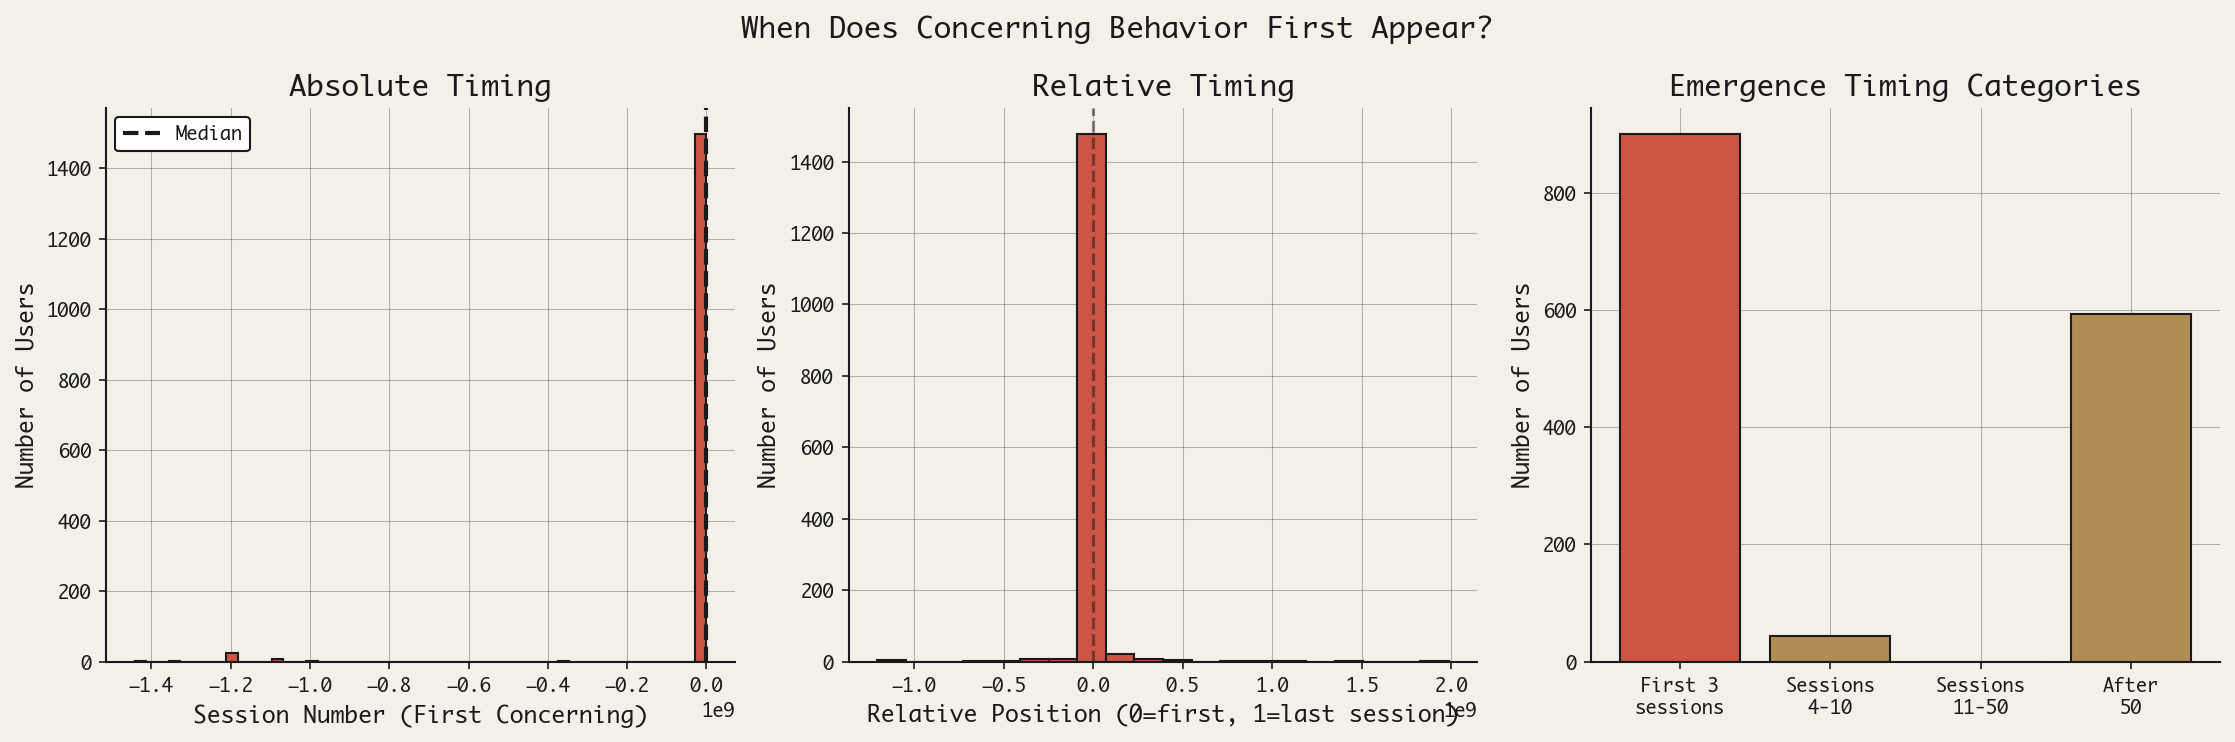


→ Concerning behavior typically emerges EARLY (59% in first 3 sessions)
  Suggests: Trait-like characteristic, not learned behavior


In [19]:
# ============================================================
# ANALYSIS 4: EMERGENCE TRAJECTORY
# ============================================================

print("="*70)
print("ANALYSIS 4: WHEN DOES CONCERNING BEHAVIOR EMERGE?")
print("="*70)

# Number each user's sessions chronologically
session_numbered = session_metrics.sort(['user_id', 'session_start']).with_columns([
    pl.lit(1).cum_sum().over('user_id').alias('session_number')
])

# Get session number of first concerning session for each user
first_concerning_per_user = concerning_sessions.sort('session_start').group_by('user_id').first()

first_concerning_with_number = first_concerning_per_user.join(
    session_numbered.select(['unique_session_id', 'session_number']),
    on='unique_session_id',
    how='left'
)

# Also get total sessions per user
user_total_sessions = session_metrics.group_by('user_id').len().rename({'len': 'total_sessions'})

first_concerning_with_number = first_concerning_with_number.join(
    user_total_sessions,
    on='user_id',
    how='left'
).with_columns([
    (pl.col('session_number') / pl.col('total_sessions')).alias('relative_position')
])

print("When Does First Concerning Session Appear?")
print(f"  Mean session number: {first_concerning_with_number['session_number'].mean():.1f}")
print(f"  Median session number: {first_concerning_with_number['session_number'].median():.0f}")
print(f"  % in first session: {(first_concerning_with_number['session_number'] == 1).mean():.1%}")
print(f"  % in first 3 sessions: {(first_concerning_with_number['session_number'] <= 3).mean():.1%}")
print(f"  % in first 10 sessions: {(first_concerning_with_number['session_number'] <= 10).mean():.1%}")
print(f"  % after 50 sessions: {(first_concerning_with_number['session_number'] > 50).mean():.1%}")

print(f"\nRelative Position (% through user's history):")
print(f"  Mean: {first_concerning_with_number['relative_position'].mean():.1%}")
print(f"  Median: {first_concerning_with_number['relative_position'].median():.1%}")
print(f"  % in first quarter: {(first_concerning_with_number['relative_position'] <= 0.25).mean():.1%}")
print(f"  % in last quarter: {(first_concerning_with_number['relative_position'] >= 0.75).mean():.1%}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('When Does Concerning Behavior First Appear?', fontsize=14, fontweight='bold')

# Panel 1: Absolute session number
ax = axes[0]
session_nums = first_concerning_with_number['session_number'].clip(None, 100).to_numpy()
ax.hist(session_nums, bins=50, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvline(x=first_concerning_with_number['session_number'].median(), 
           color=BRAND['ink'], linestyle='--', linewidth=2, label='Median')
ax.set_xlabel('Session Number (First Concerning)')
ax.set_ylabel('Number of Users')
ax.set_title('Absolute Timing')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Relative position
ax = axes[1]
rel_positions = first_concerning_with_number['relative_position'].to_numpy()
ax.hist(rel_positions, bins=20, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvline(x=0.5, color=BRAND['ink'], linestyle='--', alpha=0.5)
ax.set_xlabel('Relative Position (0=first, 1=last session)')
ax.set_ylabel('Number of Users')
ax.set_title('Relative Timing')
apply_phronos_style(ax)

# Panel 3: Early vs late emergers
ax = axes[2]
categories = ['First 3\nsessions', 'Sessions\n4-10', 'Sessions\n11-50', 'After\n50']
counts = [
    (first_concerning_with_number['session_number'] <= 3).sum(),
    ((first_concerning_with_number['session_number'] > 3) & 
     (first_concerning_with_number['session_number'] <= 10)).sum(),
    ((first_concerning_with_number['session_number'] > 10) & 
     (first_concerning_with_number['session_number'] <= 50)).sum(),
    (first_concerning_with_number['session_number'] > 50).sum(),
]
colors = [BRAND['alert'], BRAND['gold'], BRAND['gold'], BRAND['gold']]
ax.bar(categories, counts, color=colors, edgecolor=BRAND['ink'])
ax.set_ylabel('Number of Users')
ax.set_title('Emergence Timing Categories')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'concerning_emergence_timing')
plt.show()

# Interpretation
early_emergers = (first_concerning_with_number['session_number'] <= 3).mean()
if early_emergers > 0.5:
    print(f"\n→ Concerning behavior typically emerges EARLY ({early_emergers:.0%} in first 3 sessions)")
    print("  Suggests: Trait-like characteristic, not learned behavior")
else:
    print(f"\n→ Concerning behavior often emerges LATER ({1-early_emergers:.0%} after session 3)")
    print("  Suggests: Developed pattern, possible escalation")


In [23]:
# ============================================================
# ANALYSIS 5: MATCHED CONTROL COMPARISON
# ============================================================

print("="*70)
print("ANALYSIS 5: MATCHED CONTROL ANALYSIS")
print("="*70)

# Get user-level metrics for all users
user_metrics = session_metrics.group_by('user_id').agg([
    pl.len().alias('n_sessions'),
    pl.col('total_turns').sum().alias('total_turns'),
    pl.col('session_toxicity_ratio').mean().alias('mean_toxicity'),
    pl.col('span_hours').mean().alias('mean_session_span'),
])

# Add late night and weekend ratios if available
if 'is_late_night' in session_metrics.columns:
    user_metrics = user_metrics.join(
        session_metrics.group_by('user_id').agg([
            pl.col('is_late_night').mean().alias('late_night_ratio'),
            pl.col('is_weekend').mean().alias('weekend_ratio'),
        ]),
        on='user_id',
        how='left'
    )
else:
    user_metrics = user_metrics.with_columns([
        pl.lit(None).alias('late_night_ratio'),
        pl.lit(None).alias('weekend_ratio'),
    ])

# Identify concerning vs non-concerning users
concerning_user_metrics = user_metrics.filter(pl.col('user_id').is_in(concerning_user_ids))
control_pool = user_metrics.filter(~pl.col('user_id').is_in(concerning_user_ids))

print(f"Concerning users: {len(concerning_user_metrics):,}")
print(f"Control pool: {len(control_pool):,}")

# Match on total sessions (within ±20%)
def find_matched_controls(concerning_users, control_pool, match_col='n_sessions', tolerance=0.2):
    """
    For each concerning user, find a matched control with similar session count.
    """
    matched_pairs = []
    used_controls = set()
    
    for row in concerning_users.iter_rows(named=True):
        target = row[match_col]
        lower = target * (1 - tolerance)
        upper = target * (1 + tolerance)
        
        candidates = control_pool.filter(
            (pl.col(match_col) >= lower) & 
            (pl.col(match_col) <= upper) &
            (~pl.col('user_id').is_in(list(used_controls)))
        )
        
        if len(candidates) > 0:
            # Pick random match
            match = candidates.sample(1, seed=hash(row['user_id']) % 2**32)
            matched_pairs.append({
                'concerning_user': row['user_id'],
                'control_user': match['user_id'][0],
                'concerning_sessions': row[match_col],
                'control_sessions': match[match_col][0],
            })
            used_controls.add(match['user_id'][0])
    
    return matched_pairs

print("\nMatching concerning users to controls...")
matched_pairs = find_matched_controls(concerning_user_metrics, control_pool)
print(f"Successfully matched: {len(matched_pairs):,} pairs")

if len(matched_pairs) > 0:
    # Extract matched control user IDs
    control_user_ids = [p['control_user'] for p in matched_pairs]
    matched_concerning_ids = [p['concerning_user'] for p in matched_pairs]
    
    matched_concerning = user_metrics.filter(pl.col('user_id').is_in(matched_concerning_ids))
    matched_controls = user_metrics.filter(pl.col('user_id').is_in(control_user_ids))
    
    # Compare
    print(f"\nMatched Comparison (controlling for session count):")
    print(f"{'Metric':<25} {'Concerning':>15} {'Control':>15} {'Diff':>15}")
    print("-" * 70)
    
    metrics_to_compare = [
        ('n_sessions', 'Sessions'),
        ('total_turns', 'Total turns'),
        ('mean_toxicity', 'Mean toxicity'),
        ('mean_session_span', 'Mean span (hrs)'),
    ]
    
    # Add optional metrics if available
    if 'late_night_ratio' in matched_concerning.columns and matched_concerning['late_night_ratio'].is_not_null().any():
        metrics_to_compare.append(('late_night_ratio', 'Late night %'))
    if 'weekend_ratio' in matched_concerning.columns and matched_concerning['weekend_ratio'].is_not_null().any():
        metrics_to_compare.append(('weekend_ratio', 'Weekend %'))
    
    for col, label in metrics_to_compare:
        conc_vals = matched_concerning[col].drop_nulls().to_numpy()
        ctrl_vals = matched_controls[col].drop_nulls().to_numpy()
        
        if len(conc_vals) > 0 and len(ctrl_vals) > 0:
            conc_val = np.mean(conc_vals)
            ctrl_val = np.mean(ctrl_vals)
            
            if ctrl_val > 0:
                diff_pct = (conc_val - ctrl_val) / ctrl_val * 100
                diff_str = f"{diff_pct:+.1f}%"
            else:
                diff_str = f"{conc_val - ctrl_val:+.3f}"
            
            print(f"{label:<25} {conc_val:>15.3f} {ctrl_val:>15.3f} {diff_str:>15}")
    
    # Statistical tests
    print(f"\nStatistical Tests:")
    for col, label in metrics_to_compare[2:]:  # Skip session count (matched on this)
        conc_vals = matched_concerning[col].drop_nulls().to_numpy()
        ctrl_vals = matched_controls[col].drop_nulls().to_numpy()
        
        if len(conc_vals) > 0 and len(ctrl_vals) > 0:
            stat, p = mannwhitneyu(
                conc_vals,
                ctrl_vals,
                alternative='two-sided'
            )
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {label}: p = {p:.4f} {sig}")
else:
    print("No matched pairs found.")


ANALYSIS 5: MATCHED CONTROL ANALYSIS
Concerning users: 1,537
Control pool: 220,506

Matching concerning users to controls...
Successfully matched: 1,532 pairs

Matched Comparison (controlling for session count):
Metric                         Concerning         Control            Diff
----------------------------------------------------------------------
Sessions                           18.072          17.352           +4.1%
Total turns                       420.368         110.519         +280.4%
Mean toxicity                       0.298           0.166          +79.9%
Mean span (hrs)                     5.906           1.352         +336.7%

Statistical Tests:
  Mean toxicity: p = 0.0000 ***
  Mean span (hrs): p = 0.0000 ***


ANALYSIS 6: CLASSIFYING CONCERNING SESSION SEGMENTS
Segment Distribution:
  extended_general_use                   944 ( 41.8%) [Concern Level: 1]
  problematic_content                    630 ( 27.9%) [Concern Level: 3]
  extended_late_night                    367 ( 16.2%) [Concern Level: 2]
  problematic_content_late_night         170 (  7.5%) [Concern Level: 4]
  high_intensity_unknown                 148 (  6.6%) [Concern Level: 2]

Concern Level Summary:
  Level 1 (Low): 944 (41.8%)
  Level 2 (Medium): 515 (22.8%)
  Level 3 (Higher): 630 (27.9%)
  Level 4 (Highest): 170 (7.5%)
Saved: ../outputs/figures/pub_concerning_segments.png


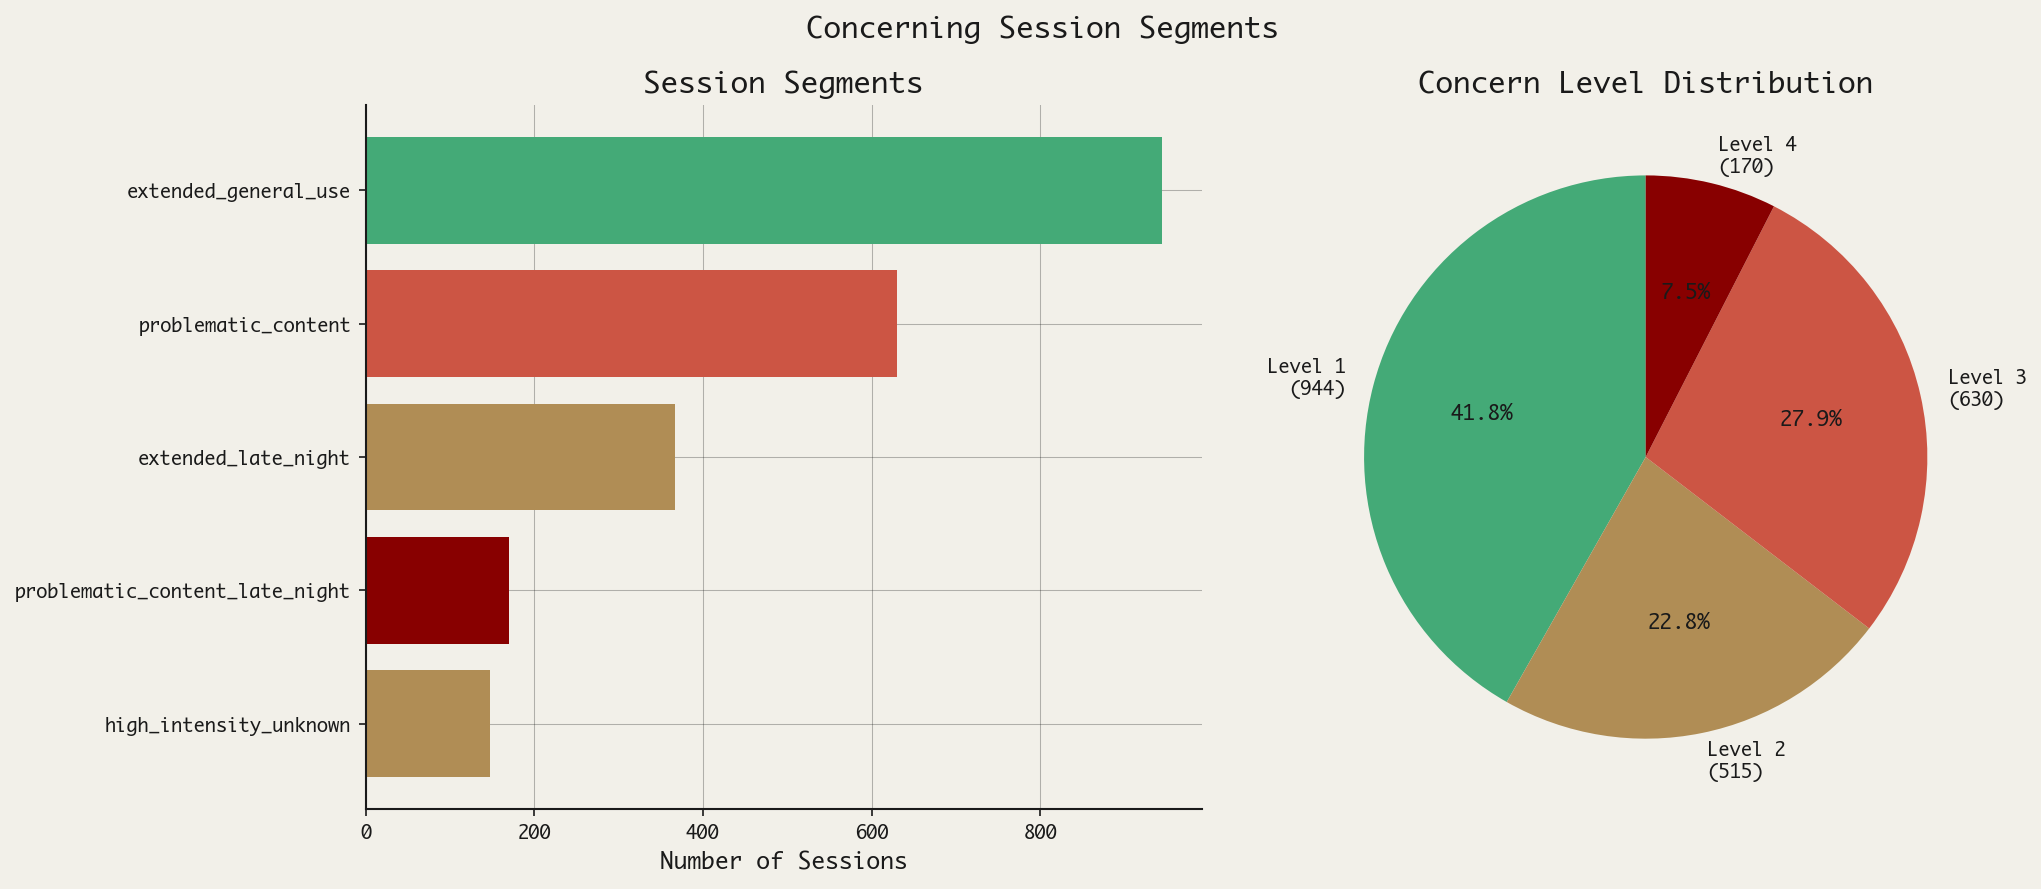

In [24]:
# ============================================================
# ANALYSIS 6: SEGMENT CLASSIFICATION
# ============================================================

print("="*70)
print("ANALYSIS 6: CLASSIFYING CONCERNING SESSION SEGMENTS")
print("="*70)

# Classify each concerning session into segments based on characteristics
def classify_concerning_session(row):
    """
    Classify a concerning session into a segment.
    
    Returns: segment label and concern level (1-4)
    """
    toxicity = row.get('session_toxicity_ratio', 0)
    is_late_night = row.get('is_late_night', False)
    turns_per_hour = row.get('turns_per_hour', 0)
    
    # Segment logic
    if toxicity > 0.5:
        if is_late_night:
            return 'problematic_content_late_night', 4
        else:
            return 'problematic_content', 3
    
    if turns_per_hour > 20:
        return 'high_intensity_unknown', 2
    
    if is_late_night:
        return 'extended_late_night', 2
    
    return 'extended_general_use', 1

# Apply classification
segments = []
concern_levels = []

for row in concerning_sessions.iter_rows(named=True):
    segment, level = classify_concerning_session(row)
    segments.append(segment)
    concern_levels.append(level)

concerning_sessions = concerning_sessions.with_columns([
    pl.Series('segment', segments),
    pl.Series('concern_level', concern_levels),
])

# Segment distribution
print("Segment Distribution:")
segment_counts = concerning_sessions.group_by('segment').agg([
    pl.len().alias('count'),
    pl.col('concern_level').first().alias('concern_level'),
]).sort('count', descending=True)

for row in segment_counts.iter_rows(named=True):
    pct = 100 * row['count'] / len(concerning_sessions)
    print(f"  {row['segment']:<35} {row['count']:>6,} ({pct:>5.1f}%) "
          f"[Concern Level: {row['concern_level']}]")

# Concern level summary
print("\nConcern Level Summary:")
level_counts = concerning_sessions.group_by('concern_level').len().sort('concern_level')
for row in level_counts.iter_rows(named=True):
    pct = 100 * row['len'] / len(concerning_sessions)
    level_desc = {1: 'Low', 2: 'Medium', 3: 'Higher', 4: 'Highest'}[row['concern_level']]
    print(f"  Level {row['concern_level']} ({level_desc}): {row['len']:,} ({pct:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Concerning Session Segments', fontsize=14, fontweight='bold')

# Panel 1: Segment distribution
ax = axes[0]
segments_sorted = segment_counts.sort('count', descending=True)
colors = [
    BRAND['success'] if l == 1 else 
    BRAND['gold'] if l == 2 else 
    BRAND['alert'] if l == 3 else 
    '#880000'  # Dark red for level 4
    for l in segments_sorted['concern_level'].to_list()
]

ax.barh(segments_sorted['segment'].to_list()[::-1], 
        segments_sorted['count'].to_list()[::-1],
        color=colors[::-1])
ax.set_xlabel('Number of Sessions')
ax.set_title('Session Segments')
apply_phronos_style(ax)

# Panel 2: Concern level pie chart
ax = axes[1]
level_data = concerning_sessions.group_by('concern_level').len().sort('concern_level')
labels = [f"Level {r['concern_level']}\n({r['len']:,})" for r in level_data.iter_rows(named=True)]
sizes = level_data['len'].to_list()
colors_pie = [BRAND['success'], BRAND['gold'], BRAND['alert'], '#880000'][:len(sizes)]

ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax.set_title('Concern Level Distribution')

plt.tight_layout()
save_figure(fig, 'concerning_segments')
plt.show()


Saved: ../outputs/figures/pub_concerning_sessions_dashboard.png


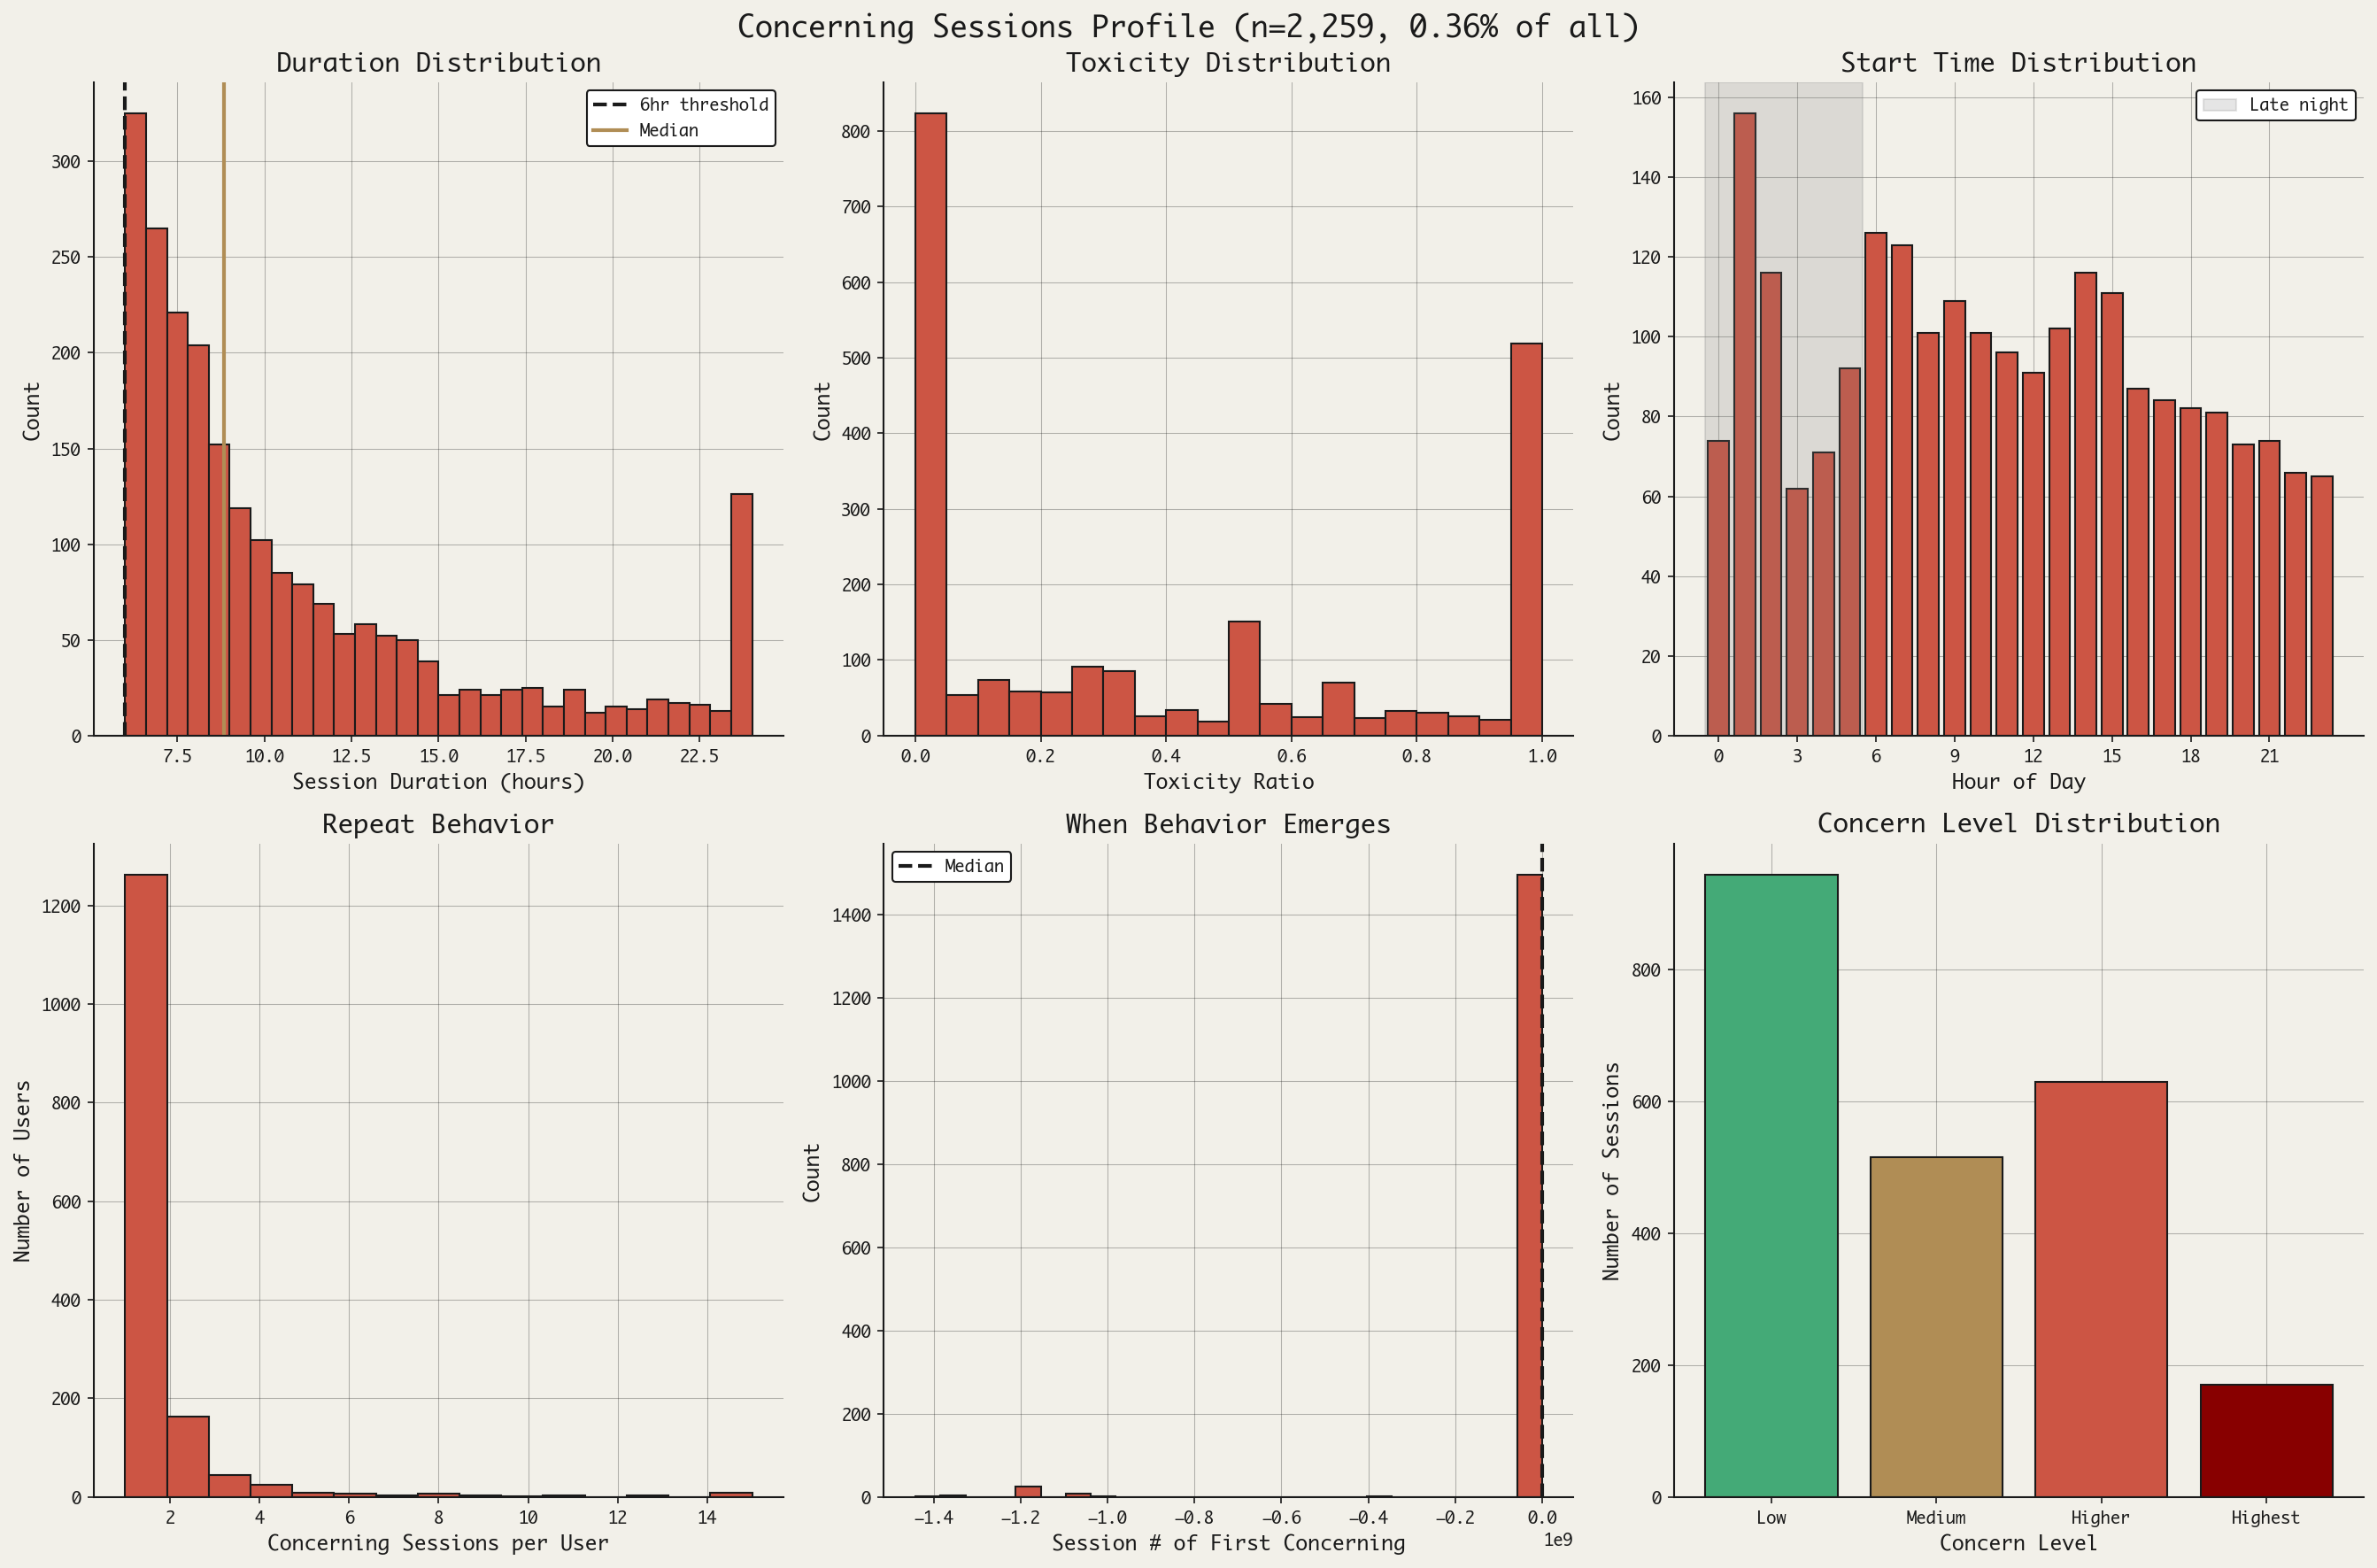

In [25]:
# ============================================================
# SUMMARY VISUALIZATION: CONCERNING SESSION PROFILE DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Concerning Sessions Profile (n={len(concerning_sessions):,}, {100*len(concerning_sessions)/len(session_metrics):.2f}% of all)', 
             fontsize=16, fontweight='bold')

# Panel 1: Session duration distribution
ax = axes[0, 0]
ax.hist(concerning_sessions['span_hours'].clip(None, 24).to_numpy(), 
        bins=30, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvline(x=6, color=BRAND['ink'], linestyle='--', linewidth=2, label='6hr threshold')
ax.axvline(x=concerning_sessions['span_hours'].median(), 
           color=BRAND['gold'], linestyle='-', linewidth=2, label='Median')
ax.set_xlabel('Session Duration (hours)')
ax.set_ylabel('Count')
ax.set_title('Duration Distribution')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Toxicity distribution
ax = axes[0, 1]
ax.hist(concerning_sessions['session_toxicity_ratio'].to_numpy(), 
        bins=20, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.set_xlabel('Toxicity Ratio')
ax.set_ylabel('Count')
ax.set_title('Toxicity Distribution')
apply_phronos_style(ax)

# Panel 3: Start hour heatmap-style
ax = axes[0, 2]
hours_df = concerning_sessions.group_by('start_hour').len().sort('start_hour')
hours = hours_df['start_hour'].to_numpy()
counts = hours_df['len'].to_numpy()
ax.bar(hours, counts, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvspan(-0.5, 5.5, alpha=0.2, color='gray', label='Late night')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count')
ax.set_title('Start Time Distribution')
ax.set_xticks(range(0, 24, 3))
ax.legend()
apply_phronos_style(ax)

# Panel 4: Sessions per user
ax = axes[1, 0]
ax.hist(user_concerning_counts['n_concerning'].clip(None, 15).to_numpy(),
        bins=15, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.set_xlabel('Concerning Sessions per User')
ax.set_ylabel('Number of Users')
ax.set_title('Repeat Behavior')
apply_phronos_style(ax)

# Panel 5: Emergence timing
ax = axes[1, 1]
ax.hist(first_concerning_with_number['session_number'].clip(None, 50).to_numpy(),
        bins=25, color=BRAND['alert'], edgecolor=BRAND['ink'])
ax.axvline(x=first_concerning_with_number['session_number'].median(),
           color=BRAND['ink'], linestyle='--', linewidth=2, label='Median')
ax.set_xlabel('Session # of First Concerning')
ax.set_ylabel('Count')
ax.set_title('When Behavior Emerges')
ax.legend()
apply_phronos_style(ax)

# Panel 6: Concern level breakdown
ax = axes[1, 2]
level_data = concerning_sessions.group_by('concern_level').len().sort('concern_level')
levels = level_data['concern_level'].to_list()
counts = level_data['len'].to_list()
level_labels = ['Low', 'Medium', 'Higher', 'Highest']
colors_bar = [BRAND['success'], BRAND['gold'], BRAND['alert'], '#880000']

ax.bar([level_labels[l-1] for l in levels], counts, 
       color=[colors_bar[l-1] for l in levels], edgecolor=BRAND['ink'])
ax.set_xlabel('Concern Level')
ax.set_ylabel('Number of Sessions')
ax.set_title('Concern Level Distribution')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'concerning_sessions_dashboard')
plt.show()


In [26]:
# ============================================================
# SUMMARY REPORT
# ============================================================

print("="*70)
print("CONCERNING SESSIONS ANALYSIS: SUMMARY REPORT")
print("="*70)

report = f"""
CONCERNING SESSIONS DEEP DIVE ANALYSIS
======================================

OVERVIEW
--------
Total sessions analyzed: {len(session_metrics):,}
Concerning sessions: {len(concerning_sessions):,} ({100*len(concerning_sessions)/len(session_metrics):.2f}%)
Users with concerning sessions: {len(concerning_user_ids):,}

CONCERNING SESSION CHARACTERISTICS
----------------------------------
Mean span: {concerning_sessions['span_hours'].mean():.1f} hours
Median span: {concerning_sessions['span_hours'].median():.1f} hours
Mean turns/hour: {concerning_sessions['turns_per_hour'].mean():.1f}
Mean total turns: {concerning_sessions['total_turns'].mean():.0f}

TOXICITY
--------
Sessions with any toxic content: {concerning_sessions['is_toxic'].mean():.1%}
Sessions >50% toxic: {(concerning_sessions['session_toxicity_ratio'] > 0.5).mean():.1%}
Mean toxicity ratio: {concerning_sessions['session_toxicity_ratio'].mean():.3f}

(vs Normal sessions: {normal_sessions['is_toxic'].mean():.1%} any toxic, mean ratio {normal_sessions['session_toxicity_ratio'].mean():.3f})

TEMPORAL PATTERNS
-----------------
Late night starts (0-5am): {concerning_sessions['is_late_night'].mean():.1%}
Weekend sessions: {concerning_sessions['is_weekend'].mean():.1%}

(vs Normal: {normal_sessions['is_late_night'].mean():.1%} late night, {normal_sessions['is_weekend'].mean():.1%} weekend)

USER PERSISTENCE
----------------
Users with exactly 1 concerning session: {(user_concerning_counts['n_concerning'] == 1).mean():.1%}
Users with 3+ concerning sessions: {(user_concerning_counts['n_concerning'] >= 3).mean():.1%}
Maximum concerning sessions per user: {user_concerning_counts['n_concerning'].max()}

EMERGENCE TIMING
----------------
Median session # of first concerning: {first_concerning_with_number['session_number'].median():.0f}
% appearing in first 3 sessions: {(first_concerning_with_number['session_number'] <= 3).mean():.1%}

SEGMENT BREAKDOWN
-----------------
"""

for row in segment_counts.iter_rows(named=True):
    pct = 100 * row['count'] / len(concerning_sessions)
    report += f"  {row['segment']}: {row['count']:,} ({pct:.1f}%)\n"

report += f"""
CONCERN LEVEL DISTRIBUTION
--------------------------
Level 1 (Low - e.g., extended general use): {(concerning_sessions['concern_level'] == 1).mean():.1%}
Level 2 (Medium - e.g., high intensity): {(concerning_sessions['concern_level'] == 2).mean():.1%}
Level 3 (Higher - e.g., problematic content): {(concerning_sessions['concern_level'] == 3).mean():.1%}
Level 4 (Highest - e.g., problematic + late night): {(concerning_sessions['concern_level'] == 4).mean():.1%}

KEY FINDINGS
------------
1. {len(concerning_sessions):,} sessions ({100*len(concerning_sessions)/len(session_metrics):.2f}%) meet concerning criteria
2. Mean session span: {concerning_sessions['span_hours'].mean():.1f} hours (median: {concerning_sessions['span_hours'].median():.1f})
3. Toxicity overlap: {(concerning_sessions['session_toxicity_ratio'] > 0.5).mean():.1%} of concerning sessions are >50% toxic
4. User persistence: {(user_concerning_counts['n_concerning'] >= 3).mean():.1%} of users have 3+ concerning sessions
5. Emergence: {(first_concerning_with_number['session_number'] <= 3).mean():.1%} of first concerning sessions appear in first 3 sessions

LIMITATIONS
-----------
- Toxicity labels are coarse (binary at conversation level)
- Cannot observe outcomes (wellbeing, life impact)
- Selection bias: only users who use this platform
- Session grouping based on 30-minute gap threshold may not capture all patterns
"""

print(report)

# Save report
with open('../outputs/concerning_sessions_report.txt', 'w') as f:
    f.write(report)
print("\nSaved report: ../outputs/concerning_sessions_report.txt")

# Update session_metrics with segment and concern_level for future use
session_metrics = session_metrics.join(
    concerning_sessions.select(['unique_session_id', 'segment', 'concern_level']),
    on='unique_session_id',
    how='left'
)

# Save updated session metrics
output_path = '../outputs/data/session_metrics.parquet'
session_metrics.write_parquet(output_path)
print(f"Updated session metrics saved to: {output_path}")

print("\n" + "="*70)
print("Concerning sessions deep dive analysis complete.")
print("="*70)


CONCERNING SESSIONS ANALYSIS: SUMMARY REPORT

CONCERNING SESSIONS DEEP DIVE ANALYSIS

OVERVIEW
--------
Total sessions analyzed: 622,589
Concerning sessions: 2,259 (0.36%)
Users with concerning sessions: 1,537

CONCERNING SESSION CHARACTERISTICS
----------------------------------
Mean span: 11.3 hours
Median span: 8.8 hours
Mean turns/hour: 13.2
Mean total turns: 130

TOXICITY
--------
Sessions with any toxic content: 41.6%
Sessions >50% toxic: 35.4%
Mean toxicity ratio: 0.403

(vs Normal sessions: 16.6% any toxic, mean ratio 0.157)

TEMPORAL PATTERNS
-----------------
Late night starts (0-5am): 25.3%
Weekend sessions: 41.2%

(vs Normal: 21.0% late night, 38.3% weekend)

USER PERSISTENCE
----------------
Users with exactly 1 concerning session: 82.2%
Users with 3+ concerning sessions: 7.3%
Maximum concerning sessions per user: 38

EMERGENCE TIMING
----------------
Median session # of first concerning: 0
% appearing in first 3 sessions: 58.6%

SEGMENT BREAKDOWN
-----------------
  exten